In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress
import glob

valid_combinations = [
    (1, 1), (1, 2), (1, 1000),  # r1i1p1f1, r1i2p1f1, r1i1000p1f1
    (2, 1),                     # r2i1p1f1
    (3, 1),                     # r3i1p1f1
    (4, 1),                     # r4i1p1f1
    (5, 1),                     # r5i1p1f1
    (6, 1),                     # r6i1p1f1
    (7, 1),                     # r7i1p1f1
    (8, 1),                     # r8i1p1f1
    (9, 1),                     # r9i1p1f1
    (10, 1)                     # r10i1p1f1
]

# Generate file paths only for valid combinations
files_historical = [
    f'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_historical_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations
]
file_SSP119 = 'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp119_r4i1p1f1_g025.nc'
files_SSP126 = [f'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp126_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
#missingi3
files_SSP245 = [f'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp245_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
files_SSP370 = [f'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp370_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
file_SSP434 = 'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp434_r1i1p1f1_g025.nc'
file_SSP460 = 'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp460_r1i1p1f1_g025.nc'
file_SSP534 = 'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp534-over_r1i1p1f1_g025.nc'
valid_combinations_ssp585 = [
    (1, 1), (1, 2),  # r1i1p1f1, r1i2p1f1
    (2, 1),          # r2i1p1f1
    (3, 1),          # r3i1p1f1
    (4, 1),          # r4i1p1f1
    (5, 1)           # r5i1p1f1
]

# Generate file paths only for the valid combinations
files_SSP585 = [
    f'E:/Jubjang/FWICMIP6/fwisa_ann_MRI-ESM2-0_ssp585_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations_ssp585
]

# Function to load datasets from a list of file paths
# def load_datasets(file_list):
#     datasets = []
#     for file in file_list:
#         try:
#             ds = xr.open_dataset(file)
#             datasets.append(ds)
#         except Exception as e:
#             print(f"Error loading {file}: {e}")
#     return datasets
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

# Load datasets
datasets_historical = load_datasets(files_historical)
dataset_SSP119 = xr.open_mfdataset(file_SSP119, combine='by_coords', engine='netcdf4')
datasets_SSP126 = load_datasets(files_SSP126)
datasets_SSP245 = load_datasets(files_SSP245)
datasets_SSP370 = load_datasets(files_SSP370)
dataset_SSP434 = xr.open_mfdataset(file_SSP434, combine='by_coords', engine='netcdf4')
dataset_SSP460 = xr.open_mfdataset(file_SSP460, combine='by_coords', engine='netcdf4')
dataset_SSP534 = xr.open_mfdataset(file_SSP534, combine='by_coords', engine='netcdf4')
datasets_SSP585 = load_datasets(files_SSP585)

print("Datasets successfully loaded!")

Datasets successfully loaded!


In [2]:
# Define CFDatetimeCoder for proper time decoding
time_coder = xr.coding.times.CFDatetimeCoder(use_cftime=True)

# Generate file paths only for valid combinations
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

files_pr_historical = [
    f'E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]
file_pr_SSP119 = 'E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_201501-210012.nc'
files_pr_SSP126_r1 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_pr_SSP126_r2 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_pr_SSP126_r3 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_pr_SSP126_r4 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_pr_SSP126_r5 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_pr_SSP245_r1 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_pr_SSP245_r2 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_pr_SSP245_r3 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_pr_SSP245_r4 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_pr_SSP245_r5 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))
files_pr_SSP370 = glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc")
file_pr_SSP434 = 'E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp434_r1i1p1f1_gn_*.nc'
file_pr_SSP460 = 'E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn_*.nc'
files_pr_SSP534_r1 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn*.nc"))
files_pr_SSP585_r1i1 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_pr_SSP585_r1i2 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_pr_SSP585_r2 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_pr_SSP585_r3 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_pr_SSP585_r4 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_pr_SSP585_r5 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))
# Load datasets
datasets_pr_historical = load_datasets(files_pr_historical)
dataset_pr_SSP119 = xr.open_mfdataset(file_pr_SSP119, combine='by_coords', engine='netcdf4')


datasets_pr_SSP245_r1 = xr.open_mfdataset(files_pr_SSP245_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP245_r2 = xr.open_mfdataset(files_pr_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP245_r3 = xr.open_mfdataset(files_pr_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP245_r4 = xr.open_mfdataset(files_pr_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP245_r5 = xr.open_mfdataset(files_pr_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP245 = xr.concat([datasets_pr_SSP245_r1, datasets_pr_SSP245_r2, datasets_pr_SSP245_r3, datasets_pr_SSP245_r4, datasets_pr_SSP245_r5], dim="ensemble")

datasets_pr_SSP126_r1 = xr.open_mfdataset(files_pr_SSP126_r1, combine="nested", concat_dim="time", engine="netcdf4",  decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP126_r2 = xr.open_mfdataset(files_pr_SSP126_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP126_r3 = xr.open_mfdataset(files_pr_SSP126_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP126_r4 = xr.open_mfdataset(files_pr_SSP126_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP126_r5 = xr.open_mfdataset(files_pr_SSP126_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_pr_SSP126 = xr.concat([datasets_pr_SSP126_r1, datasets_pr_SSP126_r2, datasets_pr_SSP126_r3, datasets_pr_SSP126_r4, datasets_pr_SSP126_r5], dim="ensemble")

# Load datasets individually and add "ensemble" as a coordinate
datasets_pr_SSP370 = [
    xr.open_dataset(file).assign_coords(ensemble=i)
    for i, file in enumerate(files_pr_SSP370)
]

# Merge all datasets along the "ensemble" dimension
datasets_pr_SSP370 = xr.concat(datasets_pr_SSP370, dim="ensemble")
dataset_pr_SSP434 = xr.open_mfdataset(file_pr_SSP434, combine='by_coords', engine='netcdf4')
dataset_pr_SSP460 = xr.open_mfdataset(file_pr_SSP460, combine='by_coords', engine='netcdf4')
datasets_pr_SSP534 = xr.open_mfdataset(files_pr_SSP534_r1, combine="nested", concat_dim="time", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r1i1 = xr.open_mfdataset(files_pr_SSP585_r1i1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r1i2 = xr.open_mfdataset(files_pr_SSP585_r1i2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r2 = xr.open_mfdataset(files_pr_SSP585_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r3 = xr.open_mfdataset(files_pr_SSP585_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r4 = xr.open_mfdataset(files_pr_SSP585_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585_r5 = xr.open_mfdataset(files_pr_SSP585_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_pr_SSP585 = xr.concat([datasets_pr_SSP585_r1i1, datasets_pr_SSP585_r1i2, datasets_pr_SSP585_r2, datasets_pr_SSP585_r3, datasets_pr_SSP585_r4, datasets_pr_SSP585_r5], dim="ensemble")

In [3]:
datasets_pr_historical = xr.concat(datasets_pr_historical, dim="ensemble")

In [4]:
datasets_pr_all_scenarios = [
    datasets_pr_historical,
    dataset_pr_SSP119,
    datasets_pr_SSP126,
    datasets_pr_SSP245,
    datasets_pr_SSP370,
    dataset_pr_SSP434,
    dataset_pr_SSP460,
    datasets_pr_SSP534,
    datasets_pr_SSP585
]

In [5]:
# Generate file paths for tasmax
files_tasmax_historical = [
    f'E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]
file_tasmax_SSP119 = "E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_201501-210012.nc"

files_tasmax_SSP126_r1 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r2 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r3 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r4 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r5 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_tasmax_SSP245_r1 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_tasmax_SSP245_r2 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_tasmax_SSP245_r3 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_tasmax_SSP245_r4 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_tasmax_SSP245_r5 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))

files_tasmax_SSP370 = glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc")
files_tasmax_SSP585_r1i1 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_tasmax_SSP585_r1i2 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_tasmax_SSP585_r2 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_tasmax_SSP585_r3 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_tasmax_SSP585_r4 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_tasmax_SSP585_r5 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

files_tasmax_SSP434 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp434_r1i1p1f1_gn*.nc"))
files_tasmax_SSP460 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn*.nc"))
files_tasmax_SSP534 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp534-over_r*i1p1f1_gn*.nc"))
# Load datasets
datasets_tasmax_historical = load_datasets(files_tasmax_historical)
dataset_tasmax_SSP119 = xr.open_mfdataset(file_tasmax_SSP119, combine="by_coords", engine="netcdf4")

datasets_tasmax_SSP245_r1 = xr.open_mfdataset(files_tasmax_SSP245_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP245_r2 = xr.open_mfdataset(files_tasmax_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP245_r3 = xr.open_mfdataset(files_tasmax_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP245_r4 = xr.open_mfdataset(files_tasmax_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP245_r5 = xr.open_mfdataset(files_tasmax_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_tasmax_SSP245 = xr.concat([datasets_tasmax_SSP245_r1, datasets_tasmax_SSP245_r2, datasets_tasmax_SSP245_r3, datasets_tasmax_SSP245_r4, datasets_tasmax_SSP245_r5], dim="ensemble")

datasets_tasmax_SSP126_r1 = xr.open_mfdataset(files_tasmax_SSP126_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP126_r2 = xr.open_mfdataset(files_tasmax_SSP126_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP126_r3 = xr.open_mfdataset(files_tasmax_SSP126_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP126_r4 = xr.open_mfdataset(files_tasmax_SSP126_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP126_r5 = xr.open_mfdataset(files_tasmax_SSP126_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_tasmax_SSP126 = xr.concat([datasets_tasmax_SSP126_r1, datasets_tasmax_SSP126_r2, datasets_tasmax_SSP126_r3, datasets_tasmax_SSP126_r4, datasets_tasmax_SSP126_r5], dim="ensemble")

# Load datasets individually and add "ensemble" as a coordinate
datasets_tasmax_SSP370 = [
    xr.open_dataset(file).assign_coords(ensemble=i)
    for i, file in enumerate(files_tasmax_SSP370)
]

# Merge all datasets along the "ensemble" dimension
datasets_tasmax_SSP370 = xr.concat(datasets_tasmax_SSP370, dim="ensemble")

datasets_tasmax_SSP585_r1i1 = xr.open_mfdataset(files_tasmax_SSP585_r1i1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585_r1i2 = xr.open_mfdataset(files_tasmax_SSP585_r1i2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585_r2 = xr.open_mfdataset(files_tasmax_SSP585_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585_r3 = xr.open_mfdataset(files_tasmax_SSP585_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585_r4 = xr.open_mfdataset(files_tasmax_SSP585_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585_r5 = xr.open_mfdataset(files_tasmax_SSP585_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_tasmax_SSP585 = xr.concat([datasets_tasmax_SSP585_r1i1, datasets_tasmax_SSP585_r1i2, datasets_tasmax_SSP585_r2, datasets_tasmax_SSP585_r3, datasets_tasmax_SSP585_r4, datasets_tasmax_SSP585_r5], dim="ensemble")

dataset_tasmax_SSP434 = xr.open_mfdataset(files_tasmax_SSP434, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
dataset_tasmax_SSP460 = xr.open_mfdataset(files_tasmax_SSP460, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
dataset_tasmax_SSP534 = xr.open_mfdataset(files_tasmax_SSP534, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

In [6]:
# Generate file paths only for valid combinations
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

files_sfcWind_historical = [
    f'E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]
file_sfcWind_SSP119 = 'E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_201501-210012.nc'
files_sfcWind_SSP126_r1 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r2 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r3 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r4 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r5 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_sfcWind_SSP245_r1 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_sfcWind_SSP245_r2 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_sfcWind_SSP245_r3 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_sfcWind_SSP245_r4 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_sfcWind_SSP245_r5 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))
files_sfcWind_SSP370 = glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc")
file_sfcWind_SSP434 = 'E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp434_r1i1p1f1_gn_*.nc'
file_sfcWind_SSP460 = 'E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn_*.nc'
files_sfcWind_SSP534_r1 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r1i1 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn_*.nc"))
files_sfcWind_SSP585_r1i2 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn_201501-210012.nc"))
files_sfcWind_SSP585_r2 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r3 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r4 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r5 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

# Load datasets
datasets_sfcWind_historical = load_datasets(files_sfcWind_historical)
dataset_sfcWind_SSP119 = xr.open_mfdataset(file_sfcWind_SSP119, combine='by_coords', engine='netcdf4')

datasets_sfcWind_SSP245_r1 = xr.open_mfdataset(files_sfcWind_SSP245_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP245_r2 = xr.open_mfdataset(files_sfcWind_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP245_r3 = xr.open_mfdataset(files_sfcWind_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP245_r4 = xr.open_mfdataset(files_sfcWind_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP245_r5 = xr.open_mfdataset(files_sfcWind_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_sfcWind_SSP245 = xr.concat([datasets_sfcWind_SSP245_r1, datasets_sfcWind_SSP245_r2, datasets_sfcWind_SSP245_r3, datasets_sfcWind_SSP245_r4, datasets_sfcWind_SSP245_r5], dim="ensemble")


datasets_sfcWind_SSP126_r1 = xr.open_mfdataset(files_sfcWind_SSP126_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP126_r2 = xr.open_mfdataset(files_sfcWind_SSP126_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP126_r3 = xr.open_mfdataset(files_sfcWind_SSP126_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP126_r4 = xr.open_mfdataset(files_sfcWind_SSP126_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP126_r5 = xr.open_mfdataset(files_sfcWind_SSP126_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_sfcWind_SSP126 = xr.concat([datasets_sfcWind_SSP126_r1, datasets_sfcWind_SSP126_r2, datasets_sfcWind_SSP126_r3, datasets_sfcWind_SSP126_r4, datasets_sfcWind_SSP126_r5], dim="ensemble")

# Load datasets individually and add "ensemble" as a coordinate
datasets_sfcWind_SSP370 = [
    xr.open_dataset(file).assign_coords(ensemble=i)
    for i, file in enumerate(files_sfcWind_SSP370)
]

# Merge all datasets along the "ensemble" dimension
datasets_sfcWind_SSP370 = xr.concat(datasets_sfcWind_SSP370, dim="ensemble")
dataset_sfcWind_SSP434 = xr.open_mfdataset(file_sfcWind_SSP434, combine='by_coords', engine='netcdf4')
dataset_sfcWind_SSP460 = xr.open_mfdataset(file_sfcWind_SSP460, combine='by_coords', engine='netcdf4')
datasets_sfcWind_SSP534 = xr.open_mfdataset(files_sfcWind_SSP534_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_sfcWind_SSP585_r1i1 = xr.open_mfdataset(files_sfcWind_SSP585_r1i1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP585_r1i2 = xr.open_mfdataset(files_sfcWind_SSP585_r1i2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP585_r2 = xr.open_mfdataset(files_sfcWind_SSP585_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP585_r3 = xr.open_mfdataset(files_sfcWind_SSP585_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP585_r4 = xr.open_mfdataset(files_sfcWind_SSP585_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_sfcWind_SSP585_r5 = xr.open_mfdataset(files_sfcWind_SSP585_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_sfcWind_SSP585 = xr.concat([datasets_sfcWind_SSP585_r1i1, datasets_sfcWind_SSP585_r1i2, datasets_sfcWind_SSP585_r2, datasets_sfcWind_SSP585_r3, datasets_sfcWind_SSP585_r4, datasets_sfcWind_SSP585_r5], dim="ensemble")


In [7]:
datasets_sfcWind_historical = xr.concat(datasets_sfcWind_historical, dim="ensemble")

In [8]:
datasets_sfcWind_all_scenarios = [
    datasets_sfcWind_historical,
    dataset_sfcWind_SSP119,
    datasets_sfcWind_SSP126,
    datasets_sfcWind_SSP245,
    datasets_sfcWind_SSP370,
    dataset_sfcWind_SSP434,
    dataset_sfcWind_SSP460,
    datasets_sfcWind_SSP534,
    datasets_sfcWind_SSP585
]


In [9]:
# Define CFDatetimeCoder for proper time decoding
time_coder = xr.coding.times.CFDatetimeCoder(use_cftime=True)

# Generate file paths for hurs
files_hurs_historical = [
    f'E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]
file_hurs_SSP119 = "E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_201501-210012.nc"

files_hurs_SSP126_r1 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_hurs_SSP126_r2 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_hurs_SSP126_r3 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_hurs_SSP126_r4 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_hurs_SSP126_r5 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_hurs_SSP245_r1 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_hurs_SSP245_r2 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_hurs_SSP245_r3 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_hurs_SSP245_r4 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_hurs_SSP245_r5 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))

files_hurs_SSP370 = glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc")
files_hurs_SSP585_r1i1 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_hurs_SSP585_r1i2 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_hurs_SSP585_r2 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_hurs_SSP585_r3 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_hurs_SSP585_r4 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_hurs_SSP585_r5 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

files_hurs_SSP434 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp434_r1i1p1f1_gn*.nc"))
files_hurs_SSP460 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn*.nc"))
files_hurs_SSP534 = sorted(glob.glob("E:/Jubjang/hurs/hurs_Amon_MRI-ESM2-0_ssp534-over_r*i1p1f1_gn*.nc"))

# Load datasets
datasets_hurs_historical = load_datasets(files_hurs_historical)
dataset_hurs_SSP119 = xr.open_mfdataset(file_hurs_SSP119, combine="by_coords", engine="netcdf4")

datasets_hurs_SSP245_r1 = xr.open_mfdataset(files_hurs_SSP245_r1, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP245_r2 = xr.open_mfdataset(files_hurs_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP245_r3 = xr.open_mfdataset(files_hurs_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP245_r4 = xr.open_mfdataset(files_hurs_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP245_r5 = xr.open_mfdataset(files_hurs_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_hurs_SSP245 = xr.concat([datasets_hurs_SSP245_r1, datasets_hurs_SSP245_r2, datasets_hurs_SSP245_r3, datasets_hurs_SSP245_r4, datasets_hurs_SSP245_r5], dim="ensemble")


datasets_hurs_SSP126_r1 = xr.open_mfdataset(files_hurs_SSP126_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP126_r2 = xr.open_mfdataset(files_hurs_SSP126_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP126_r3 = xr.open_mfdataset(files_hurs_SSP126_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP126_r4 = xr.open_mfdataset(files_hurs_SSP126_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP126_r5 = xr.open_mfdataset(files_hurs_SSP126_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_hurs_SSP126 = xr.concat([datasets_hurs_SSP126_r1, datasets_hurs_SSP126_r2, datasets_hurs_SSP126_r3, datasets_hurs_SSP126_r4, datasets_hurs_SSP126_r5], dim="ensemble")

# Load datasets individually and add "ensemble" as a coordinate
datasets_hurs_SSP370 = [
    xr.open_dataset(file).assign_coords(ensemble=i)
    for i, file in enumerate(files_hurs_SSP370)
]

# Merge all datasets along the "ensemble" dimension
datasets_hurs_SSP370 = xr.concat(datasets_hurs_SSP370, dim="ensemble")

datasets_hurs_SSP585_r1i1 = xr.open_mfdataset(files_hurs_SSP585_r1i1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP585_r1i2 = xr.open_mfdataset(files_hurs_SSP585_r1i2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP585_r2 = xr.open_mfdataset(files_hurs_SSP585_r2, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP585_r3 = xr.open_mfdataset(files_hurs_SSP585_r3, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP585_r4 = xr.open_mfdataset(files_hurs_SSP585_r4, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP585_r5 = xr.open_mfdataset(files_hurs_SSP585_r5, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})

datasets_hurs_SSP585 = xr.concat([datasets_hurs_SSP585_r1i1, datasets_hurs_SSP585_r1i2, datasets_hurs_SSP585_r2, datasets_hurs_SSP585_r3, datasets_hurs_SSP585_r4, datasets_hurs_SSP585_r5], dim="ensemble")


dataset_hurs_SSP434 = xr.open_mfdataset(files_hurs_SSP434, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
dataset_hurs_SSP460 = xr.open_mfdataset(files_hurs_SSP460, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_hurs_SSP534 = xr.open_mfdataset(files_hurs_SSP534, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})


In [10]:
datasets_hurs_historical = xr.concat(datasets_hurs_historical, dim="ensemble")

In [11]:
datasets_hurs_all_scenarios = [
    datasets_hurs_historical,
    dataset_hurs_SSP119,
    datasets_hurs_SSP126,
    datasets_hurs_SSP245,
    datasets_hurs_SSP370,
    dataset_hurs_SSP434,
    dataset_hurs_SSP460,
    datasets_hurs_SSP534,
    datasets_hurs_SSP585
]


In [12]:
datasets_tasmax_historical = xr.concat(datasets_tasmax_historical, dim="ensemble")

In [13]:
file_tas_areacella = "E:/Jubjang/pr/areacella_fx_MRI-ESM2-0_ssp370_r1i1p1f1_gn.nc"
areacella_tas = xr.open_mfdataset(file_tas_areacella, combine="by_coords", engine="netcdf4")
areacella_tas['areacella'].load()

<xarray.DataArray 'areacella' (lat: 160, lon: 320)> Size: 205kB
array([[2.2957566e+08, 2.2957566e+08, 2.2957566e+08, ..., 2.2957566e+08,
        2.2957566e+08, 2.2957566e+08],
       [5.3432307e+08, 5.3432307e+08, 5.3432307e+08, ..., 5.3432307e+08,
        5.3432307e+08, 5.3432307e+08],
       [8.3931718e+08, 8.3931718e+08, 8.3931718e+08, ..., 8.3931718e+08,
        8.3931718e+08, 8.3931718e+08],
       ...,
       [8.3931718e+08, 8.3931718e+08, 8.3931718e+08, ..., 8.3931718e+08,
        8.3931718e+08, 8.3931718e+08],
       [5.3432307e+08, 5.3432307e+08, 5.3432307e+08, ..., 5.3432307e+08,
        5.3432307e+08, 5.3432307e+08],
       [2.2957566e+08, 2.2957566e+08, 2.2957566e+08, ..., 2.2957566e+08,
        2.2957566e+08, 2.2957566e+08]], shape=(160, 320), dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -89.14 -88.03 -86.91 -85.79 ... 86.91 88.03 89.14
  * lon      (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 355.5 356.6 357.8 358.9
Attributes:
    standard_name:  cell_area
    long_name:      Grid-Cell Area for Atmospheric Grid Variables
    comment:        For atmospheres with more than 1 mesh (e.g., staggered gr...
    units:          m2
    original_name:  area
    cell_methods:   area: sum
    history:        2019-05-24T05:35:18Z altered by CMOR: replaced missing va...

In [14]:
datasets_tasmax_all_scenarios = [
    datasets_tasmax_historical,
    dataset_tasmax_SSP119,
    datasets_tasmax_SSP126,
    datasets_tasmax_SSP245,
    datasets_tasmax_SSP370,
    dataset_tasmax_SSP434,
    dataset_tasmax_SSP460,
    dataset_tasmax_SSP534,
    datasets_tasmax_SSP585
]


In [15]:
# Define Earth's radius in meters
R = 6378137

# Latitude and longitude arrays (in degrees)
lon = datasets_historical[0].coords['lon']
lat = datasets_historical[0].coords['lat']

# Convert to radians
lon_radians = np.radians(lon)
lat_radians = np.radians(lat)

# Calculate the differences in longitude and latitude
delta_lon = np.diff(lon_radians)[0]  # Assuming regular grid
delta_lat = np.diff(lat_radians).mean()  # Take the mean for approximate spacing

# Calculate area for each grid cell
area = np.zeros((len(lat), len(lon)))  # Initialize area array to match full grid

for i in range(len(lat)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    elif i == len(lat) - 1:  # Northernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    else:  # Interior latitudes
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2

    # Calculate area for this latitude band
    area[i, :] = (R**2 * delta_lon * (np.sin(phi2) - np.sin(phi1)))

# Convert to square kilometers
area_km2 = area / 1e6

# Print or save the area array
print("Area array (in km^2):", area_km2)
print("Shape of area array:", area_km2.shape)


Area array (in km^2): [[1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 ...
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]]
Shape of area array: (72, 144)


In [16]:
# Latitude and longitude arrays (in degrees)
lon_pr = datasets_pr_SSP370.coords['lon']
lat_pr = datasets_pr_SSP370.coords['lat']

# Convert to radians
lon_pr_radians = np.radians(lon_pr)
lat_pr_radians = np.radians(lat_pr)

# Calculate the differences in longitude and latitude
delta_lon_pr = np.diff(lon_pr_radians)[0]  # Assuming regular grid
delta_lat_pr = np.diff(lat_pr_radians).mean()  # Take the mean for approximate spacing

# Initialize area array to match full grid
area_pr = np.zeros((len(lat_pr), len(lon_pr)))

for i in range(len(lat_pr)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1_pr = lat_pr_radians[i] - delta_lat_pr / 2
        phi2_pr = lat_pr_radians[i] + delta_lat_pr / 2
    elif i == len(lat_pr) - 1:  # Northernmost edge
        phi1_pr = lat_pr_radians[i] - delta_lat_pr / 2
        phi2_pr = lat_pr_radians[i] + delta_lat_pr / 2
    else:  # Interior latitudes
        phi1_pr = lat_pr_radians[i] - delta_lat_pr / 2
        phi2_pr = lat_pr_radians[i] + delta_lat_pr / 2

    # Calculate area for this latitude band
    area_pr[i, :] = (R**2 * delta_lon_pr * (np.sin(phi2_pr) - np.sin(phi1_pr)))

# Convert to square kilometers
area_km2_pr = area_pr / 1e6  

# Print or save the area array
print("Area array (in km^2):", area_km2_pr)
print("Shape of area array:", area_km2_pr.shape)


Area array (in km^2): [[234.20287408 234.20287408 234.20287408 ... 234.20287408 234.20287408
  234.20287408]
 [537.50750505 537.50750505 537.50750505 ... 537.50750505 537.50750505
  537.50750505]
 [842.39948191 842.39948191 842.39948191 ... 842.39948191 842.39948191
  842.39948191]
 ...
 [842.39948191 842.39948191 842.39948191 ... 842.39948191 842.39948191
  842.39948191]
 [537.50750505 537.50750505 537.50750505 ... 537.50750505 537.50750505
  537.50750505]
 [234.20287408 234.20287408 234.20287408 ... 234.20287408 234.20287408
  234.20287408]]
Shape of area array: (160, 320)


In [17]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat = 72  # Number of latitude points
num_lon = 144  # Number of longitude points
lat = np.linspace(-88.75, 88.75, num_lat)  # Correct number of points
lon = np.linspace(1.25, 358.75, num_lon)  # Correct number of points

# Create the DataArray
areacella = xr.DataArray(
    area_km2,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella = xr.Dataset({"area": areacella})

# Inspect the Dataset
print(areacella)

<xarray.Dataset> Size: 85kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 83kB 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03


In [18]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat_pr = 160  # Number of latitude points
num_lon_pr = 320  # Number of longitude points
lat_pr = np.linspace(-89.14152, 89.14152, num_lat_pr)  # Correct number of points
lon_pr = np.linspace(0.0, 358.875, num_lon_pr)  # Correct number of points

# Create the DataArray
areacella_pr = xr.DataArray(
    area_km2_pr,
    dims=["lat", "lon"],
    coords={"lat": lat_pr, "lon": lon_pr},
    name="area_pr"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella_pr = xr.Dataset({"area": areacella_pr})

# Inspect the Dataset
print(areacella_pr)

<xarray.Dataset> Size: 413kB
Dimensions:  (lat: 160, lon: 320)
Coordinates:
  * lat      (lat) float64 1kB -89.14 -88.02 -86.9 -85.78 ... 86.9 88.02 89.14
  * lon      (lon) float64 3kB 0.0 1.125 2.25 3.375 ... 355.5 356.6 357.8 358.9
Data variables:
    area     (lat, lon) float64 410kB 234.2 234.2 234.2 ... 234.2 234.2 234.2


In [19]:
# Latitude and longitude range for Thailand (adjust as needed based on data)
thailand_lat_range = slice(5.5, 20.5)  # Latitude range for Thailand (from 20.5°N to 5.5°N)
thailand_lon_range = slice(97.5, 105.5)  # Longitude range for Thailand (from 97.5°E to 105.5°E)
    
areacella_th=areacella.sel(lat=thailand_lat_range, lon=thailand_lon_range)
areacella_pr_th=areacella_pr.sel(lat=thailand_lat_range, lon=thailand_lon_range)

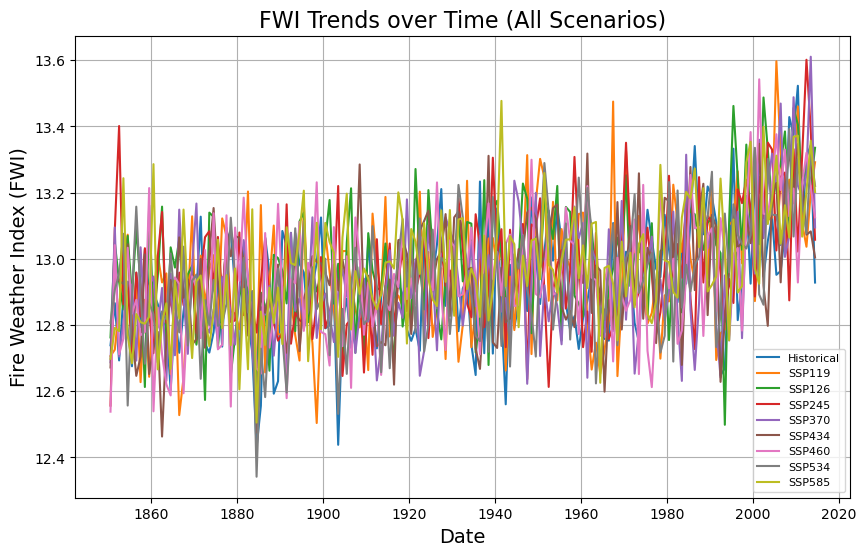

In [20]:
from datetime import datetime

def plot_fwi_trends(datasets, labels, title):
    """ 
    Plot FWI trends over time for given datasets. 
    
    Args:
        datasets (list): List of xarray datasets.
        labels (list): Corresponding labels for each dataset.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(10, 6))
    
    # Plot each dataset
    for dataset, label in zip(datasets, labels):
        plt.plot(
            dataset['time'], 
            dataset['fwisa'].mean(dim=['lat', 'lon']), 
            label=label
        )
    
    # Plot customization
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Fire Weather Index (FWI)', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

# Group datasets and labels
datasets_all_scenarios = (
    datasets_historical +
    [dataset_SSP119] +
    datasets_SSP126 +
    datasets_SSP245 +
    datasets_SSP370 +
    [dataset_SSP434] +
    [dataset_SSP460]  +
    [dataset_SSP534] +
    datasets_SSP585
)

labels_all_scenarios = (
    ['Historical'] + 
        ['SSP119'] + 
        ['SSP126'] + 
        ['SSP245'] + 
        ['SSP370'] + 
        ['SSP434'] +
        ['SSP460'] +
        ['SSP534'] +
        ['SSP585']
#     [f'Historical r{i}i1p1f1' for i in range(1, 11)] +
#     ['SSP119 r4i1p1f1'] +
#     [f'SSP126 r{i}i1p1f1' for i in range(1, 6)] +
#     [f'SSP245 r{i}i1p1f1' for i in range(1, 6)] +
#     [f'SSP370 r{i}i1p1f1' for i in range(1, 6)] +
#     ['SSP434 r1i1p1f1'] +
#     ['SSP460 r1i1p1f1'] +
#     ['SSP534 r1i1p1f1'] +
#     [f'SSP585 r{i}i{j}p1f1' for i, j in valid_combinations_ssp585]
)
# Plot FWI trends for all scenarios
plot_fwi_trends(datasets_all_scenarios, labels_all_scenarios, 'FWI Trends over Time (All Scenarios)')

In [21]:
def load_and_concatenate(file_list):
    datasets = [xr.open_dataset(file, engine='netcdf4') for file in file_list]
    concatenated = xr.concat(datasets, dim='ensemble')
    return concatenated

# Define a function to process and compute ensemble statistics
def process_ssp_data_th(file_list, lat_range, lon_range, area_weights):
    # Load and concatenate datasets
    ssp_data = load_and_concatenate(file_list)
    
    # Select the Thailand region based on latitude and longitude ranges
    ssp_data_th = ssp_data.sel(lat=lat_range, lon=lon_range)
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std


In [22]:
# Group datasets and labels
datasets_all_scenarios = (
    datasets_historical +
    [dataset_SSP119] +
    datasets_SSP126 +
    datasets_SSP245 +
    datasets_SSP370 +
    [dataset_SSP434] +
    [dataset_SSP460]  +
    [dataset_SSP534] +
    datasets_SSP585
)
historical_mean_th, historical_std_th = process_ssp_data_th(files_historical, thailand_lat_range, thailand_lon_range, areacella_th)
ssp119_mean_th, ssp119_std_th = process_ssp_data_th([file_SSP119], thailand_lat_range, thailand_lon_range, areacella_th)
ssp126_mean_th, ssp126_std_th = process_ssp_data_th(files_SSP126, thailand_lat_range, thailand_lon_range, areacella_th)
ssp245_mean_th, ssp245_std_th = process_ssp_data_th(files_SSP245, thailand_lat_range, thailand_lon_range, areacella_th)
ssp370_mean_th, ssp370_std_th = process_ssp_data_th(files_SSP370, thailand_lat_range, thailand_lon_range, areacella_th)
ssp434_mean_th, ssp434_std_th = process_ssp_data_th([file_SSP434], thailand_lat_range, thailand_lon_range, areacella_th)
ssp460_mean_th, ssp460_std_th = process_ssp_data_th([file_SSP460], thailand_lat_range, thailand_lon_range, areacella_th)
ssp534_mean_th, ssp534_std_th = process_ssp_data_th([file_SSP534], thailand_lat_range, thailand_lon_range, areacella_th)
ssp585_mean_th, ssp585_std_th = process_ssp_data_th(files_SSP585, thailand_lat_range, thailand_lon_range, areacella_th)

In [23]:
datasets_thailand = [
    ds.sel(lat=thailand_lat_range, lon=thailand_lon_range) for ds in datasets_all_scenarios
]

In [24]:
# Example input (replace with your actual data)
ensemble_means_th_all_scenarios = [
    historical_mean_th, ssp119_mean_th, ssp126_mean_th, ssp245_mean_th,
     ssp370_mean_th, ssp434_mean_th, ssp460_mean_th, ssp534_mean_th, ssp585_mean_th
]
ensemble_stds_th_all_scenarios = [
    historical_std_th, ssp119_std_th, ssp126_std_th, ssp245_std_th,
    ssp370_std_th, ssp434_std_th, ssp460_std_th, ssp534_std_th, ssp585_std_th
]

In [25]:
# Define scenario labels for the legend with detailed descriptions
labels_tasmax_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]


In [26]:
def compute_tasmax_means(tasmax_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for tasmax, handling non-Gregorian calendars.

    Args:
        tasmax_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for tasmax across all scenarios (in the same order as scenario_labels).
    """
    tasmax_means = []  # ✅ Use a list

    for tasmax_dataset, label in zip(tasmax_datasets, scenario_labels):
        if isinstance(tasmax_dataset, list):
            tasmax_dataset = xr.concat(tasmax_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {tasmax_dataset['time'].min().values} to {tasmax_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            tasmax_dataset = tasmax_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # Convert Kelvin to Celsius
        tasmax_celsius = tasmax_dataset['tasmax']
        tasmax_weighted = tasmax_celsius.weighted(areacella['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in tasmax_weighted.dims:
            tasmax_ensemble_mean = tasmax_weighted.mean(dim="ensemble")
        else:
            tasmax_ensemble_mean = tasmax_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(tasmax_ensemble_mean['time'].dtype, np.datetime64):
            tasmax_ensemble_mean = tasmax_ensemble_mean.assign_coords(
                time=tasmax_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution and turn celcius to kelvin
        tasmax_ensemble_mean = tasmax_ensemble_mean.resample(time="YE").mean()-273.15

        # ✅ Append instead of using dictionary keys
        tasmax_means.append(tasmax_ensemble_mean)

    return tasmax_means  # ✅ Return a list instead of a dictionary


# ✅ Compute tasmax ensemble means
tasmax_means_all_scenarios = compute_tasmax_means(
    [
        datasets_tasmax_historical,
        dataset_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        dataset_tasmax_SSP434,
        dataset_tasmax_SSP460,
        dataset_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [27]:
import numpy as np
import xarray as xr

def compute_pr_means(pr_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for precipitation (pr), handling non-Gregorian calendars.

    Args:
        pr_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for precipitation across all scenarios.
    """
    pr_means = []  

    for pr_dataset, label in zip(pr_datasets, scenario_labels):
        if isinstance(pr_dataset, list):
            pr_dataset = xr.concat(pr_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {pr_dataset['time'].min().values} to {pr_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            pr_dataset = pr_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # Extract precipitation data
        pr_values = pr_dataset['pr']

        # ✅ Convert from kg/m²/s to mm/day only if necessary
        if pr_values.max().compute() < 0.1:
            pr_values = pr_values * 86400  # Convert from kg/m²/s to mm/day

        # ✅ Compute area-weighted mean lazily
        pr_weighted = pr_values.weighted(areacella['areacella']).mean(dim=['lat', 'lon']).compute()

        # ✅ Compute ensemble mean only if "ensemble" exists
        if "ensemble" in pr_weighted.dims:
            pr_ensemble_mean = pr_weighted.mean(dim="ensemble").compute()
        else:
            pr_ensemble_mean = pr_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(pr_ensemble_mean['time'].dtype, np.datetime64):
            pr_ensemble_mean = pr_ensemble_mean.assign_coords(
                time=pr_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        pr_ensemble_mean = pr_ensemble_mean.resample(time="YE").mean()

        # ✅ Append to list instead of using dictionary keys
        pr_means.append(pr_ensemble_mean)

    return pr_means  


# ✅ Compute pr ensemble means with optimized memory usage
pr_means_all_scenarios = compute_pr_means(
    [
        datasets_pr_historical,
        dataset_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        dataset_pr_SSP434,
        dataset_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [28]:
def compute_sfcWind_means(sfcWind_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for sfcWind, handling non-Gregorian calendars.

    Args:
        sfcWind_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for sfcWind across all scenarios (in the same order as scenario_labels).
    """
    sfcWind_means = []  # ✅ Use a list

    for sfcWind_dataset, label in zip(sfcWind_datasets, scenario_labels):
        if isinstance(sfcWind_dataset, list):
            sfcWind_dataset = xr.concat(sfcWind_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {sfcWind_dataset['time'].min().values} to {sfcWind_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            sfcWind_dataset = sfcWind_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # Extract sfcWind values
        sfcWind_values = sfcWind_dataset['sfcWind']
        sfcWind_weighted = sfcWind_values.weighted(areacella['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in sfcWind_weighted.dims:
            sfcWind_ensemble_mean = sfcWind_weighted.mean(dim="ensemble")
        else:
            sfcWind_ensemble_mean = sfcWind_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(sfcWind_ensemble_mean['time'].dtype, np.datetime64):
            sfcWind_ensemble_mean = sfcWind_ensemble_mean.assign_coords(
                time=sfcWind_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        sfcWind_ensemble_mean = sfcWind_ensemble_mean.resample(time="YE").mean()

        # ✅ Append instead of using dictionary keys
        sfcWind_means.append(sfcWind_ensemble_mean)

    return sfcWind_means  # ✅ Return a list instead of a dictionary


# ✅ Compute sfcWind ensemble means
sfcWind_means_all_scenarios = compute_sfcWind_means(
    [
        datasets_sfcWind_historical,
        dataset_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        dataset_sfcWind_SSP434,
        dataset_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [29]:
def compute_hurs_means(hurs_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for hurs, handling non-Gregorian calendars.

    Args:
        hurs_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for hurs across all scenarios (in the same order as scenario_labels).
    """
    hurs_means = []  # ✅ Use a list

    for hurs_dataset, label in zip(hurs_datasets, scenario_labels):
        if isinstance(hurs_dataset, list):
            hurs_dataset = xr.concat(hurs_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {hurs_dataset['time'].min().values} to {hurs_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            hurs_dataset = hurs_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # Extract hurs values
        hurs_values = hurs_dataset['hurs']
        hurs_weighted = hurs_values.weighted(areacella['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in hurs_weighted.dims:
            hurs_ensemble_mean = hurs_weighted.mean(dim="ensemble")
        else:
            hurs_ensemble_mean = hurs_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(hurs_ensemble_mean['time'].dtype, np.datetime64):
            hurs_ensemble_mean = hurs_ensemble_mean.assign_coords(
                time=hurs_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        hurs_ensemble_mean = hurs_ensemble_mean.resample(time="YE").mean()

        # ✅ Append instead of using dictionary keys
        hurs_means.append(hurs_ensemble_mean)

    return hurs_means  # ✅ Return a list instead of a dictionary


# ✅ Compute hurs ensemble means
hurs_means_all_scenarios = compute_hurs_means(
    [
        datasets_hurs_historical,
        dataset_hurs_SSP119,
        datasets_hurs_SSP126,  
        datasets_hurs_SSP245,
        datasets_hurs_SSP370,
        dataset_hurs_SSP434,
        dataset_hurs_SSP460,
        datasets_hurs_SSP534,
        datasets_hurs_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [30]:
# Define a function to process and compute ensemble statistics
def process_ssp_data(file_list, area_weights):
    # Load and concatenate datasets
    ssp_data = load_and_concatenate(file_list)
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std

historical_mean, historical_std = process_ssp_data(files_historical, areacella_th)
ssp119_mean, ssp119_std = process_ssp_data([file_SSP119], areacella_th)
ssp126_mean, ssp126_std = process_ssp_data(files_SSP126, areacella_th)
ssp245_mean, ssp245_std = process_ssp_data(files_SSP245, areacella_th)
ssp370_mean, ssp370_std = process_ssp_data(files_SSP370, areacella_th)
ssp434_mean, ssp434_std = process_ssp_data([file_SSP434], areacella_th)
ssp460_mean, ssp460_std = process_ssp_data([file_SSP460], areacella_th)
ssp534_mean, ssp534_std = process_ssp_data([file_SSP534], areacella_th)
ssp585_mean, ssp585_std = process_ssp_data(files_SSP585, areacella_th)

In [31]:
ensemble_means_all_scenarios = [
    historical_mean, ssp119_mean, ssp126_mean, ssp245_mean,
     ssp370_mean, ssp434_mean, ssp460_mean, ssp534_mean, ssp585_mean
]
ensemble_stds_all_scenarios = [
    historical_std, ssp119_std, ssp126_std, ssp245_std,
    ssp370_std, ssp434_std, ssp460_std, ssp534_std, ssp585_std
]

In [32]:
color_blind_palette = {
        "Historical": "#000000",  # black
        "SSP119": "#E69F00",      # orange
        "SSP126": "#56B4E9",      # sky blue
        "SSP245": "#009E73",      # green
        "SSP370": "#882255",      # deep wine red
        "SSP434": "#E6D600",      # yellow
        "SSP460": "#D55E00",      # vermilion
        "SSP534": "#0072B2",      # navy blue
        "SSP585": "#CC79A7"       # reddish purple
    }


In [33]:
# ✅ Labels for each scenario
labels_tasmax_all_scenarios = [
    'Historical',
    'SSP1-1.9',
    'SSP1-2.6',
    'SSP2-4.5',
    'SSP3-7.0',
    'SSP4-3.4',
    'SSP4-6.0',
    'SSP5-3.4',
    'SSP5-8.5'
]

In [34]:
# Thailand
thailand_lat_range = (5.5, 20.5)
thailand_lon_range = (97.5, 105.5)

# England (converted to 0-360 longitude)
england_lat_range = (49.5, 55.5)
england_lon_range = (353.5, 1.5)  # If using (-180, 180), keep (-6.5, 1.5)

# Amazon (converted to 0-360 longitude)
amazon_lat_range = (-10.0, 5.0)
amazon_lon_range = (285.0, 310.0)  # If using (-180, 180), keep (-75.0, -50.0)

# Philippines
philippines_lat_range = (5.0, 20.0)
philippines_lon_range = (115.0, 130.0)


In [35]:
def compute_tasmax_means_region(tasmax_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for tasmax in a specified region, handling longitude wrapping if needed.

    Args:
        tasmax_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for tasmax across all scenarios.
    """
    tasmax_means = []

    for tasmax_dataset, label in zip(tasmax_datasets, scenario_labels):
        if isinstance(tasmax_dataset, list):
            tasmax_dataset = xr.concat(tasmax_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {tasmax_dataset['time'].min().values} to {tasmax_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            tasmax_dataset = tasmax_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # ✅ Select the dataset for the given latitude range
        tasmax_subset = tasmax_dataset['tasmax'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # ✅ Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # ✅ If longitude is in (-180, 180), convert to (0, 360) for consistency
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # ✅ If lon_min < lon_max (normal case), select directly
        if lon_min < lon_max:
            tasmax_subset = tasmax_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # ✅ If the region crosses 0° longitude (e.g., England, Alaska), select two parts
            tasmax_subset = xr.concat([
                tasmax_subset.sel(lon=slice(lon_min, 360)),
                tasmax_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # ✅ Compute area-weighted mean
        tasmax_weighted = tasmax_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in tasmax_weighted.dims:
            tasmax_ensemble_mean = tasmax_weighted.mean(dim="ensemble") 
        else:
            tasmax_ensemble_mean = tasmax_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(tasmax_ensemble_mean['time'].dtype, np.datetime64):
            tasmax_ensemble_mean = tasmax_ensemble_mean.assign_coords(
                time=tasmax_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        tasmax_ensemble_mean = tasmax_ensemble_mean.resample(time="YE").mean()-273.15

        # ✅ Append to the list instead of using dictionary keys
        tasmax_means.append(tasmax_ensemble_mean)

    return tasmax_means


# ✅ Compute tasmax ensemble means for Thailand region
tasmax_means_all_scenarios_th = compute_tasmax_means_region(
    [
        datasets_tasmax_historical,
        dataset_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        dataset_tasmax_SSP434,
        dataset_tasmax_SSP460,
        dataset_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,  
    lon_range=thailand_lon_range  
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [36]:
tasmax_means_all_scenarios_eng = compute_tasmax_means_region(
    [
        datasets_tasmax_historical,
        dataset_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        dataset_tasmax_SSP434,
        dataset_tasmax_SSP460,
        dataset_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=england_lat_range,  # Amazon Region Latitude Range
    lon_range=england_lon_range  # Amazon Region Longitude Range
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [37]:
tasmax_means_all_scenarios_ph = compute_tasmax_means_region(
    [
        datasets_tasmax_historical,
        dataset_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        dataset_tasmax_SSP434,
        dataset_tasmax_SSP460,
        dataset_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=philippines_lat_range,  #Philippines Latitude Range
    lon_range=philippines_lon_range  # Philippines Longitude Range
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [38]:
tasmax_means_all_scenarios_amazon = compute_tasmax_means_region(
    [
        datasets_tasmax_historical,
        dataset_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        dataset_tasmax_SSP434,
        dataset_tasmax_SSP460,
        dataset_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=amazon_lat_range,  # Amazon Latitude Range
    lon_range=amazon_lon_range # Amazon Longitude Range (Converted from -75 to -50)
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [39]:
def process_ssp_data_region(file_list, lat_range, lon_range, areacella):
    datasets = [xr.open_dataset(file) for file in file_list]

    processed_datasets = []
    for ds in datasets:
        # Select region
        ds_region = ds.sel(lat=slice(lat_range[0], lat_range[1]))

        # Handle longitude wrapping
        lon_min, lon_max = lon_range
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        if lon_min < lon_max:
            ds_region = ds_region.sel(lon=slice(lon_min, lon_max))
        else:
            ds_region = xr.concat([
                ds_region.sel(lon=slice(lon_min, 360)),
                ds_region.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # Compute area-weighted mean
        areacella_region = areacella.sel(lat=slice(lat_range[0], lat_range[1]))
        if lon_min < lon_max:
            areacella_region = areacella_region.sel(lon=slice(lon_min, lon_max))
        else:
            areacella_region = xr.concat([
                areacella_region.sel(lon=slice(lon_min, 360)),
                areacella_region.sel(lon=slice(0, lon_max))
            ], dim="lon")

        ds_weighted_mean = ds_region.weighted(areacella_region['area']).mean(dim=["lat", "lon"])
        processed_datasets.append(ds_weighted_mean)

    if len(processed_datasets) == 1:
        return processed_datasets[0], processed_datasets[0].std(dim="time")  #  Fix: Return actual xarray DataArray

    return xr.concat(processed_datasets, dim="ensemble").mean(dim="ensemble"), \
           xr.concat(processed_datasets, dim="ensemble").std(dim="ensemble")

#  Compute Means and Standard Deviations for England
historical_mean_eng, historical_std_eng = process_ssp_data_region(files_historical, england_lat_range, england_lon_range, areacella)

ssp119_mean_eng, ssp119_std_eng = process_ssp_data_region([file_SSP119], england_lat_range, england_lon_range, areacella)
ssp126_mean_eng, ssp126_std_eng = process_ssp_data_region(files_SSP126, england_lat_range, england_lon_range, areacella)
ssp245_mean_eng, ssp245_std_eng = process_ssp_data_region(files_SSP245, england_lat_range, england_lon_range, areacella)
ssp370_mean_eng, ssp370_std_eng = process_ssp_data_region(files_SSP370, england_lat_range, england_lon_range, areacella)
ssp434_mean_eng, ssp434_std_eng = process_ssp_data_region([file_SSP434], england_lat_range, england_lon_range, areacella)
ssp460_mean_eng, ssp460_std_eng = process_ssp_data_region([file_SSP460], england_lat_range, england_lon_range, areacella)
ssp534_mean_eng, ssp534_std_eng = process_ssp_data_region([file_SSP534], england_lat_range, england_lon_range, areacella)
ssp585_mean_eng, ssp585_std_eng = process_ssp_data_region(files_SSP585, england_lat_range, england_lon_range, areacella)

ensemble_means_eng_all_scenarios =  [
        historical_mean_eng, 
        ssp119_mean_eng, 
        ssp126_mean_eng,  
        ssp245_mean_eng, 
        ssp370_mean_eng,
        ssp434_mean_eng, 
        ssp460_mean_eng, 
        ssp534_mean_eng, 
        ssp585_mean_eng
    ]

In [40]:
# Compute Means and Standard Deviations for the Philippines
historical_mean_ph, historical_std_ph = process_ssp_data_region(files_historical, philippines_lat_range, philippines_lon_range, areacella)

ssp119_mean_ph, ssp119_std_ph = process_ssp_data_region([file_SSP119], philippines_lat_range, philippines_lon_range, areacella)
ssp126_mean_ph, ssp126_std_ph = process_ssp_data_region(files_SSP126, philippines_lat_range, philippines_lon_range, areacella)
ssp245_mean_ph, ssp245_std_ph = process_ssp_data_region(files_SSP245, philippines_lat_range, philippines_lon_range, areacella)
ssp370_mean_ph, ssp370_std_ph = process_ssp_data_region(files_SSP370, philippines_lat_range, philippines_lon_range, areacella)
ssp434_mean_ph, ssp434_std_ph = process_ssp_data_region([file_SSP434], philippines_lat_range, philippines_lon_range, areacella)
ssp460_mean_ph, ssp460_std_ph = process_ssp_data_region([file_SSP460], philippines_lat_range, philippines_lon_range, areacella)
ssp534_mean_ph, ssp534_std_ph = process_ssp_data_region([file_SSP534], philippines_lat_range, philippines_lon_range, areacella)
ssp585_mean_ph, ssp585_std_ph = process_ssp_data_region(files_SSP585, philippines_lat_range, philippines_lon_range, areacella)

# Store in a List for Compatibility
ensemble_means_ph_all_scenarios = [
    historical_mean_ph, 
    ssp119_mean_ph, 
    ssp126_mean_ph,  
    ssp245_mean_ph, 
    ssp370_mean_ph,
    ssp434_mean_ph, 
    ssp460_mean_ph, 
    ssp534_mean_ph, 
    ssp585_mean_ph
]


In [41]:
# Compute FWI Means for the Amazon
historical_mean_amazon, historical_std_amazon = process_ssp_data_region(files_historical, (-10.0, 5.0), (285.0, 310.0), areacella)

ssp119_mean_amazon, ssp119_std_amazon = process_ssp_data_region([file_SSP119], (-10.0, 5.0), (285.0, 310.0), areacella)
ssp126_mean_amazon, ssp126_std_amazon = process_ssp_data_region(files_SSP126, (-10.0, 5.0), (285.0, 310.0), areacella)
ssp245_mean_amazon, ssp245_std_amazon = process_ssp_data_region(files_SSP245, (-10.0, 5.0), (285.0, 310.0), areacella)
ssp370_mean_amazon, ssp370_std_amazon = process_ssp_data_region(files_SSP370, (-10.0, 5.0), (285.0, 310.0), areacella)
ssp434_mean_amazon, ssp434_std_amazon = process_ssp_data_region([file_SSP434], (-10.0, 5.0), (285.0, 310.0), areacella)
ssp460_mean_amazon, ssp460_std_amazon = process_ssp_data_region([file_SSP460], (-10.0, 5.0), (285.0, 310.0), areacella)
ssp534_mean_amazon, ssp534_std_amazon = process_ssp_data_region([file_SSP534], (-10.0, 5.0), (285.0, 310.0), areacella)
ssp585_mean_amazon, ssp585_std_amazon = process_ssp_data_region(files_SSP585, (-10.0, 5.0), (285.0, 310.0), areacella)

# Store in a List for Compatibility
ensemble_means_amazon_all_scenarios = [
    historical_mean_amazon, 
    ssp119_mean_amazon, 
    ssp126_mean_amazon,  
    ssp245_mean_amazon, 
    ssp370_mean_amazon,
    ssp434_mean_amazon, 
    ssp460_mean_amazon, 
    ssp534_mean_amazon, 
    ssp585_mean_amazon
]


In [42]:
def compute_pr_means_region(pr_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for precipitation (pr) in a specified region, handling longitude wrapping if needed.

    Args:
        pr_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for pr across all scenarios.
    """
    pr_means = []

    for pr_dataset, label in zip(pr_datasets, scenario_labels):
        if isinstance(pr_dataset, list):
            pr_dataset = xr.concat(pr_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {pr_dataset['time'].min().values} to {pr_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            pr_dataset = pr_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # ✅ Select the dataset for the given latitude range
        pr_subset = pr_dataset['pr'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # ✅ Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # ✅ Convert longitude to (0, 360) if necessary
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # ✅ If lon_min < lon_max (normal case), select directly
        if lon_min < lon_max:
            pr_subset = pr_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # ✅ If the region crosses 0° longitude (e.g., England, Alaska), select two parts
            pr_subset = xr.concat([
                pr_subset.sel(lon=slice(lon_min, 360)),
                pr_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # ✅ Compute area-weighted mean
        pr_weighted = pr_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in pr_weighted.dims:
            pr_ensemble_mean = pr_weighted.mean(dim="ensemble")
        else:
            pr_ensemble_mean = pr_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(pr_ensemble_mean['time'].dtype, np.datetime64):
            pr_ensemble_mean = pr_ensemble_mean.assign_coords(
                time=pr_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        pr_ensemble_mean = pr_ensemble_mean.resample(time="YE").mean()*86400

        # ✅ Append to the list instead of using dictionary keys
        pr_means.append(pr_ensemble_mean)

    return pr_means


# ✅ Compute pr ensemble means for Thailand region
pr_means_all_scenarios_th = compute_pr_means_region(
    [
        datasets_pr_historical,
        dataset_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        dataset_pr_SSP434,
        dataset_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,  # ✅ Correct: Thailand Latitude Range
    lon_range=thailand_lon_range  # ✅ Fixed: Correct Longitude Range
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [43]:
pr_means_all_scenarios_eng = compute_pr_means_region(
    [
        datasets_pr_historical,
        dataset_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        dataset_pr_SSP434,
        dataset_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=england_lat_range,  #  Thailand Region Latitude Range
    lon_range=england_lon_range  # Thailand Region Longitude Range
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [44]:
pr_means_all_scenarios_ph = compute_pr_means_region(
    [
        datasets_pr_historical,
        dataset_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        dataset_pr_SSP434,
        dataset_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=philippines_lat_range,  # ✅ Philippines Latitude Range
    lon_range=philippines_lon_range  # ✅ Philippines Longitude Range
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [45]:
pr_means_all_scenarios_amazon = compute_pr_means_region(
    [
        datasets_pr_historical,
        dataset_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        dataset_pr_SSP434,
        dataset_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=amazon_lat_range,  # ✅ Amazon Latitude Range
    lon_range=amazon_lon_range  # ✅ Amazon Longitude Range (0-360 format)
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100


In [46]:
datasets_pr_all_scenarios = [
    datasets_pr_historical,
    dataset_pr_SSP119,
    datasets_pr_SSP126,
    datasets_pr_SSP245,
    datasets_pr_SSP370,
    dataset_pr_SSP434,
    dataset_pr_SSP460,
    datasets_pr_SSP534,
    datasets_pr_SSP585
]

In [47]:
labels_pr_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]

In [48]:
def process_ssp_data_region(file_list, lat_range, lon_range, areacella):
    datasets = [xr.open_dataset(file) for file in file_list]

    processed_datasets = []
    for ds in datasets:
        # Select region
        ds_region = ds.sel(lat=slice(lat_range[0], lat_range[1]))

        # Handle longitude wrapping
        lon_min, lon_max = lon_range
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        if lon_min < lon_max:
            ds_region = ds_region.sel(lon=slice(lon_min, lon_max))
        else:
            ds_region = xr.concat([
                ds_region.sel(lon=slice(lon_min, 360)),
                ds_region.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # Compute area-weighted mean
        areacella_region = areacella.sel(lat=slice(lat_range[0], lat_range[1]))
        if lon_min < lon_max:
            areacella_region = areacella_region.sel(lon=slice(lon_min, lon_max))
        else:
            areacella_region = xr.concat([
                areacella_region.sel(lon=slice(lon_min, 360)),
                areacella_region.sel(lon=slice(0, lon_max))
            ], dim="lon")

        ds_weighted_mean = ds_region.weighted(areacella_region['area']).mean(dim=["lat", "lon"])
        processed_datasets.append(ds_weighted_mean)

    if len(processed_datasets) == 1:
        return processed_datasets[0], processed_datasets[0].std(dim="time")  

    return xr.concat(processed_datasets, dim="ensemble").mean(dim="ensemble"), \
           xr.concat(processed_datasets, dim="ensemble").std(dim="ensemble")

# ✅ Compute Means and Standard Deviations for Thailand
historical_mean_th, historical_std_th = process_ssp_data_region(files_historical, thailand_lat_range, thailand_lon_range, areacella)

ssp119_mean_th, ssp119_std_th = process_ssp_data_region([file_SSP119], thailand_lat_range, thailand_lon_range, areacella)
ssp126_mean_th, ssp126_std_th = process_ssp_data_region(files_SSP126, thailand_lat_range, thailand_lon_range, areacella)
ssp245_mean_th, ssp245_std_th = process_ssp_data_region(files_SSP245, thailand_lat_range, thailand_lon_range, areacella)
ssp370_mean_th, ssp370_std_th = process_ssp_data_region(files_SSP370, thailand_lat_range, thailand_lon_range, areacella)
ssp434_mean_th, ssp434_std_th = process_ssp_data_region([file_SSP434], thailand_lat_range, thailand_lon_range, areacella)
ssp460_mean_th, ssp460_std_th = process_ssp_data_region([file_SSP460], thailand_lat_range, thailand_lon_range, areacella)
ssp534_mean_th, ssp534_std_th = process_ssp_data_region([file_SSP534], thailand_lat_range, thailand_lon_range, areacella)
ssp585_mean_th, ssp585_std_th = process_ssp_data_region(files_SSP585, thailand_lat_range, thailand_lon_range, areacella)

# ✅ Store ensemble means for Thailand
ensemble_means_th_all_scenarios = [
    historical_mean_th, 
    ssp119_mean_th, 
    ssp126_mean_th,  
    ssp245_mean_th, 
    ssp370_mean_th,
    ssp434_mean_th, 
    ssp460_mean_th, 
    ssp534_mean_th, 
    ssp585_mean_th
]


In [49]:
# ✅ Compute Means and Standard Deviations for England
historical_mean_eng, historical_std_eng = process_ssp_data_region(files_historical, england_lat_range, england_lon_range, areacella)

ssp119_mean_eng, ssp119_std_eng = process_ssp_data_region([file_SSP119], england_lat_range, england_lon_range, areacella)
ssp126_mean_eng, ssp126_std_eng = process_ssp_data_region(files_SSP126, england_lat_range, england_lon_range, areacella)
ssp245_mean_eng, ssp245_std_eng = process_ssp_data_region(files_SSP245, england_lat_range, england_lon_range, areacella)
ssp370_mean_eng, ssp370_std_eng = process_ssp_data_region(files_SSP370, england_lat_range, england_lon_range, areacella)
ssp434_mean_eng, ssp434_std_eng = process_ssp_data_region([file_SSP434], england_lat_range, england_lon_range, areacella)
ssp460_mean_eng, ssp460_std_eng = process_ssp_data_region([file_SSP460], england_lat_range, england_lon_range, areacella)
ssp534_mean_eng, ssp534_std_eng = process_ssp_data_region([file_SSP534], england_lat_range, england_lon_range, areacella)
ssp585_mean_eng, ssp585_std_eng = process_ssp_data_region(files_SSP585, england_lat_range, england_lon_range, areacella)

# ✅ Store ensemble means for England
ensemble_means_eng_all_scenarios = [
    historical_mean_eng, 
    ssp119_mean_eng, 
    ssp126_mean_eng,  
    ssp245_mean_eng, 
    ssp370_mean_eng,
    ssp434_mean_eng, 
    ssp460_mean_eng, 
    ssp534_mean_eng, 
    ssp585_mean_eng
]

# ✅ Compute Means and Standard Deviations for the Philippines
historical_mean_ph, historical_std_ph = process_ssp_data_region(files_historical, philippines_lat_range, philippines_lon_range, areacella)

ssp119_mean_ph, ssp119_std_ph = process_ssp_data_region([file_SSP119], philippines_lat_range, philippines_lon_range, areacella)
ssp126_mean_ph, ssp126_std_ph = process_ssp_data_region(files_SSP126, philippines_lat_range, philippines_lon_range, areacella)
ssp245_mean_ph, ssp245_std_ph = process_ssp_data_region(files_SSP245, philippines_lat_range, philippines_lon_range, areacella)
ssp370_mean_ph, ssp370_std_ph = process_ssp_data_region(files_SSP370, philippines_lat_range, philippines_lon_range, areacella)
ssp434_mean_ph, ssp434_std_ph = process_ssp_data_region([file_SSP434], philippines_lat_range, philippines_lon_range, areacella)
ssp460_mean_ph, ssp460_std_ph = process_ssp_data_region([file_SSP460], philippines_lat_range, philippines_lon_range, areacella)
ssp534_mean_ph, ssp534_std_ph = process_ssp_data_region([file_SSP534], philippines_lat_range, philippines_lon_range, areacella)
ssp585_mean_ph, ssp585_std_ph = process_ssp_data_region(files_SSP585, philippines_lat_range, philippines_lon_range, areacella)

# ✅ Store ensemble means for the Philippines
ensemble_means_ph_all_scenarios = [
    historical_mean_ph, 
    ssp119_mean_ph, 
    ssp126_mean_ph,  
    ssp245_mean_ph, 
    ssp370_mean_ph,
    ssp434_mean_ph, 
    ssp460_mean_ph, 
    ssp534_mean_ph, 
    ssp585_mean_ph
]

# ✅ Compute Means and Standard Deviations for the Amazon
historical_mean_amazon, historical_std_amazon = process_ssp_data_region(files_historical, amazon_lat_range, amazon_lon_range, areacella)

ssp119_mean_amazon, ssp119_std_amazon = process_ssp_data_region([file_SSP119], amazon_lat_range, amazon_lon_range, areacella)
ssp126_mean_amazon, ssp126_std_amazon = process_ssp_data_region(files_SSP126, amazon_lat_range, amazon_lon_range, areacella)
ssp245_mean_amazon, ssp245_std_amazon = process_ssp_data_region(files_SSP245, amazon_lat_range, amazon_lon_range, areacella)
ssp370_mean_amazon, ssp370_std_amazon = process_ssp_data_region(files_SSP370, amazon_lat_range, amazon_lon_range, areacella)
ssp434_mean_amazon, ssp434_std_amazon = process_ssp_data_region([file_SSP434], amazon_lat_range, amazon_lon_range, areacella)
ssp460_mean_amazon, ssp460_std_amazon = process_ssp_data_region([file_SSP460], amazon_lat_range, amazon_lon_range, areacella)
ssp534_mean_amazon, ssp534_std_amazon = process_ssp_data_region([file_SSP534], amazon_lat_range, amazon_lon_range, areacella)
ssp585_mean_amazon, ssp585_std_amazon = process_ssp_data_region(files_SSP585, amazon_lat_range, amazon_lon_range, areacella)

# ✅ Store ensemble means for the Amazon
ensemble_means_amazon_all_scenarios = [
    historical_mean_amazon, 
    ssp119_mean_amazon, 
    ssp126_mean_amazon,  
    ssp245_mean_amazon, 
    ssp370_mean_amazon,
    ssp434_mean_amazon, 
    ssp460_mean_amazon, 
    ssp534_mean_amazon, 
    ssp585_mean_amazon
]


In [50]:
def compute_sfcWind_means_region(sfcWind_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for sfcWind in a specified region, handling longitude wrapping if needed.

    Args:
        sfcWind_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for sfcWind across all scenarios.
    """
    sfcWind_means = []

    for sfcWind_dataset, label in zip(sfcWind_datasets, scenario_labels):
        if isinstance(sfcWind_dataset, list):
            sfcWind_dataset = xr.concat(sfcWind_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {sfcWind_dataset['time'].min().values} to {sfcWind_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            sfcWind_dataset = sfcWind_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # ✅ Select the dataset for the given latitude range
        sfcWind_subset = sfcWind_dataset['sfcWind'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # ✅ Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # ✅ Convert longitude to (0, 360) if necessary
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # ✅ If lon_min < lon_max (normal case), select directly
        if lon_min < lon_max:
            sfcWind_subset = sfcWind_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # ✅ If the region crosses 0° longitude (e.g., England, Alaska), select two parts
            sfcWind_subset = xr.concat([
                sfcWind_subset.sel(lon=slice(lon_min, 360)),
                sfcWind_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # ✅ Compute area-weighted mean
        sfcWind_weighted = sfcWind_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in sfcWind_weighted.dims:
            sfcWind_ensemble_mean = sfcWind_weighted.mean(dim="ensemble")
        else:
            sfcWind_ensemble_mean = sfcWind_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(sfcWind_ensemble_mean['time'].dtype, np.datetime64):
            sfcWind_ensemble_mean = sfcWind_ensemble_mean.assign_coords(
                time=sfcWind_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Resample to annual resolution
        sfcWind_ensemble_mean = sfcWind_ensemble_mean.resample(time="YE").mean()

        # ✅ Append to the list instead of using dictionary keys
        sfcWind_means.append(sfcWind_ensemble_mean)

    return sfcWind_means


# ✅ Compute sfcWind ensemble means for Thailand region
sfcWind_means_all_scenarios_th = compute_sfcWind_means_region(
    [
        datasets_sfcWind_historical,
        dataset_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        dataset_sfcWind_SSP434,
        dataset_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,  # ✅ Correct: Thailand Latitude Range
    lon_range=thailand_lon_range  # ✅ Fixed: Correct Longitude Range
)

# Compute sfcWind ensemble means for England
sfcWind_means_all_scenarios_eng = compute_sfcWind_means_region(
    [
        datasets_sfcWind_historical,
        dataset_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        dataset_sfcWind_SSP434,
        dataset_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=england_lat_range,
    lon_range=england_lon_range
)

# Compute sfcWind ensemble means for the Philippines
sfcWind_means_all_scenarios_ph = compute_sfcWind_means_region(
    [
        datasets_sfcWind_historical,
        dataset_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        dataset_sfcWind_SSP434,
        dataset_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=philippines_lat_range,
    lon_range=philippines_lon_range
)

# Compute sfcWind ensemble means for the Amazon
sfcWind_means_all_scenarios_amazon = compute_sfcWind_means_region(
    [
        datasets_sfcWind_historical,
        dataset_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        dataset_sfcWind_SSP434,
        dataset_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=amazon_lat_range,
    lon_range=amazon_lon_range
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP585 at 2100
Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:0

In [51]:
def compute_hurs_means_region(hurs_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for hurs (relative humidity) in a specified region, handling longitude wrapping if needed.

    Args:
        hurs_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for hurs across all scenarios.
    """
    hurs_means = []

    for hurs_dataset, label in zip(hurs_datasets, scenario_labels):
        if isinstance(hurs_dataset, list):
            hurs_dataset = xr.concat(hurs_dataset, dim="ensemble", combine_attrs="drop_conflicts")

        print(f"Processing {label}: Time Range = {hurs_dataset['time'].min().values} to {hurs_dataset['time'].max().values}")

        # ✅ Cut datasets that extend beyond 2100
        if any(sub in label for sub in ["126", "534", "585"]):  
            print(f"✂ Cutting {label} at 2100")
            hurs_dataset = hurs_dataset.sel(time=slice(None, f"{end_year}-12-31"))

        # ✅ Select the dataset for the given latitude range
        hurs_subset = hurs_dataset['hurs'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # ✅ Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # ✅ Convert longitude to (0, 360) if necessary
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # ✅ If lon_min < lon_max (normal case), select directly
        if lon_min < lon_max:
            hurs_subset = hurs_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # ✅ If the region crosses 0° longitude (e.g., England, Alaska), select two parts
            hurs_subset = xr.concat([
                hurs_subset.sel(lon=slice(lon_min, 360)),
                hurs_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # ✅ Compute area-weighted mean
        hurs_weighted = hurs_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        if "ensemble" in hurs_weighted.dims:
            hurs_ensemble_mean = hurs_weighted.mean(dim="ensemble")
        else:
            hurs_ensemble_mean = hurs_weighted

        # ✅ Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        if not np.issubdtype(hurs_ensemble_mean['time'].dtype, np.datetime64):
            hurs_ensemble_mean = hurs_ensemble_mean.assign_coords(
                time=hurs_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
            )

        # ✅ Drop NaN values before resampling (fixes potential issues)
        hurs_ensemble_mean = hurs_ensemble_mean.dropna(dim="time", how="all")

        # ✅ Resample to annual resolution
        hurs_ensemble_mean = hurs_ensemble_mean.resample(time="YE").mean()

        # ✅ Append to the list instead of using dictionary keys
        hurs_means.append(hurs_ensemble_mean)

    return hurs_means


# ✅ Compute hurs ensemble means for Thailand region
hurs_means_all_scenarios_th = compute_hurs_means_region(
    [
        datasets_hurs_historical,
        dataset_hurs_SSP119,
        datasets_hurs_SSP126,  
        datasets_hurs_SSP245,
        datasets_hurs_SSP370,
        dataset_hurs_SSP434,
        dataset_hurs_SSP460,
        datasets_hurs_SSP534,
        datasets_hurs_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,  # ✅ Corrected: Thailand Latitude Range
    lon_range=thailand_lon_range  # ✅ Fixed: Correct Longitude Range
)
#  Compute hurs ensemble means for England
hurs_means_all_scenarios_eng = compute_hurs_means_region(
    [
        datasets_hurs_historical,
        dataset_hurs_SSP119,
        datasets_hurs_SSP126,  
        datasets_hurs_SSP245,
        datasets_hurs_SSP370,
        dataset_hurs_SSP434,
        dataset_hurs_SSP460,
        datasets_hurs_SSP534,
        datasets_hurs_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=england_lat_range,
    lon_range=england_lon_range
)

#  Compute hurs ensemble means for the Philippines
hurs_means_all_scenarios_ph = compute_hurs_means_region(
    [
        datasets_hurs_historical,
        dataset_hurs_SSP119,
        datasets_hurs_SSP126,  
        datasets_hurs_SSP245,
        datasets_hurs_SSP370,
        dataset_hurs_SSP434,
        dataset_hurs_SSP460,
        datasets_hurs_SSP534,
        datasets_hurs_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=philippines_lat_range,
    lon_range=philippines_lon_range
)

# Compute hurs ensemble means for the Amazon
hurs_means_all_scenarios_amazon = compute_hurs_means_region(
    [
        datasets_hurs_historical,
        dataset_hurs_SSP119,
        datasets_hurs_SSP126,  
        datasets_hurs_SSP245,
        datasets_hurs_SSP370,
        dataset_hurs_SSP434,
        dataset_hurs_SSP460,
        datasets_hurs_SSP534,
        datasets_hurs_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=amazon_lat_range,
    lon_range=amazon_lon_range
)


Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP126 at 2100
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
✂ Cutting SSP534 at 2100
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
✂ Cutting SSP585 at 2100
Processing Historical: Time Range = 1850-01-16T12:00:00.000000000 to 2014-12-16T12:00:00.000000000
Processing SSP119: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.00

In [52]:
labels_hurs_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]

In [53]:
labels_sfcWind_all_scenarios = labels_hurs_all_scenarios

In [54]:
labels_pr_all_scenarios = labels_hurs_all_scenarios

In [123]:
scenario = "Historical"
df1=tasmax_means_all_scenarios_th[0]
df2=pr_means_all_scenarios_th[0]
df3=sfcWind_means_all_scenarios_th[0]
df4=hurs_means_all_scenarios_th[0]
# Coefficients from your model for that scenario
coef = {
    "Intercept": 149.5228,
    "tasmax": 0.8114,
    "pr": 1.2177,
    "sfcWind": 0.7029,
    "hurs": -2.0748
}

# Compute predicted FWI
df["FWI_pred"] = (
    coef["Intercept"]
    + coef["tasmax"] * df1["tasmax"]
    + coef["pr"] * df2["pr"]
    + coef["sfcWind"] * df3["sfcWind"]
    + coef["hurs"] * df4["hurs"]
)


KeyError: 'tasmax'

In [125]:
def _to_series_1d(x, name):
    """
    Normalize input (xr.DataArray / pd.Series) into a pd.Series with a DatetimeIndex.
    Expects a 1D time series of yearly means.
    """
    if isinstance(x, xr.DataArray):
        if 'time' not in x.coords:
            raise ValueError(f"{name}: xarray.DataArray must have 'time' coordinate.")
        idx = pd.DatetimeIndex(pd.to_datetime(x['time'].values))
        s = pd.Series(x.values, index=idx, name=name)
    elif isinstance(x, pd.Series):
        s = x.copy()
        if not isinstance(s.index, pd.DatetimeIndex):
            s.index = pd.to_datetime(s.index)
        s.name = name
    else:
        raise TypeError(f"{name}: expected xr.DataArray or pd.Series, got {type(x)}")

    # Ensure sorted & de-duplicated by year (keep first if duplicates)
    s = s.sort_index()
    year_index = s.index.to_period('Y').to_timestamp('Y')
    s = pd.Series(s.values, index=year_index, name=name)
    s = s[~s.index.duplicated(keep='first')]
    return s

def _align_to_years(src: pd.Series, target_years: pd.DatetimeIndex) -> pd.Series:
    """
    Reindex src by nearest year to match target_years (which are year-end timestamps).
    """
    src_years = src.index.to_period('Y').to_timestamp('Y')
    s2 = pd.Series(src.values, index=src_years, name=src.name)
    # nearest match by index (years)
    return s2.reindex(target_years, method='nearest')

def prepare_panel_th_for_mlr(
    fwi_means_list, tas_means_list, pr_means_list, hurs_means_list, wind_means_list,
    labels,
    *,
    fwi_var='fwisa', tas_var='tasmax', pr_var='pr', hurs_var='hurs', wind_var='sfcWind',
    tas_in_kelvin=False,      # True if tas means are still Kelvin -> convert to °C
    pr_in_kg_m2_s=False       # True if pr is kg m^-2 s^-1 -> convert to mm/day
):
    """
    Build a panel DataFrame for MLR using precomputed (Thailand) yearly means per scenario.
    Inputs are lists aligned by scenario index.

    Returns DataFrame with columns:
      ['time','scenario','FWI','tasmax','pr','hurs','sfcWind']
    """
    rows = []

    for fwi_m, tas_m, pr_m, hurs_m, wind_m, label in zip(
        fwi_means_list, tas_means_list, pr_means_list, hurs_means_list, wind_means_list, labels
    ):
        # Normalize to pd.Series with yearly DatetimeIndex
        fwi_s   = _to_series_1d(fwi_m if not isinstance(fwi_m, xr.Dataset) else fwi_m[fwi_var], 'FWI')
        tas_s   = _to_series_1d(tas_m if not isinstance(tas_m, xr.Dataset) else tas_m[tas_var], 'tasmax')
        pr_s    = _to_series_1d(pr_m  if not isinstance(pr_m,  xr.Dataset) else pr_m[pr_var],   'pr')
        hurs_s  = _to_series_1d(hurs_m if not isinstance(hurs_m, xr.Dataset) else hurs_m[hurs_var], 'hurs')
        wind_s  = _to_series_1d(wind_m if not isinstance(wind_m, xr.Dataset) else wind_m[wind_var], 'sfcWind')

        # Align all to FWI years
        target_years = fwi_s.index.to_period('Y').to_timestamp('Y')
        tas_s  = _align_to_years(tas_s,  target_years)
        pr_s   = _align_to_years(pr_s,   target_years)
        hurs_s = _align_to_years(hurs_s, target_years)
        wind_s = _align_to_years(wind_s, target_years)
        fwi_s  = fwi_s.reindex(target_years)  # already those years

        # Unit conversions
        if tas_in_kelvin:
            tas_s = tas_s - 273.15          # -> °C
        if pr_in_kg_m2_s:
            pr_s = pr_s * 86400.0           # -> mm/day

        # Assemble scenario chunk
        df = pd.DataFrame({
            'time'   : target_years.year.astype(int),
            'FWI'    : pd.to_numeric(fwi_s.values,   errors='coerce'),
            'tasmax' : pd.to_numeric(tas_s.values,   errors='coerce'),
            'pr'     : pd.to_numeric(pr_s.values,    errors='coerce'),
            'hurs'   : pd.to_numeric(hurs_s.values,  errors='coerce'),
            'sfcWind': pd.to_numeric(wind_s.values,  errors='coerce'),
            'scenario': label
        })
        rows.append(df)

    panel_df = pd.concat(rows, ignore_index=True)

    # Clean for MLR
    panel_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    panel_df.dropna(subset=['FWI','tasmax','pr','hurs','sfcWind'], inplace=True)
    panel_df['time'] = panel_df['time'].astype(int)

    return panel_df

In [127]:
panel_df_th = prepare_panel_th_for_mlr(
    fwi_means_list=ensemble_means_th_all_scenarios,     # yearly FWI means (1D)
    tas_means_list=tasmax_means_all_scenarios_th,          # yearly tasmax means
    pr_means_list=pr_means_all_scenarios_th,            # yearly pr means
    hurs_means_list=hurs_means_all_scenarios_th,        # yearly RH means
    wind_means_list=sfcWind_means_all_scenarios_th,     # yearly wind means
    labels=labels_tasmax_all_scenarios,
    tas_in_kelvin=False,     # set True if tas list is still in Kelvin
    pr_in_kg_m2_s=False      # set True if pr list is kg m^-2 s^-1
)

print(panel_df_th.head())
print(panel_df_th.groupby('scenario').size())


   time        FWI     tasmax        pr       hurs   sfcWind    scenario
0  1850  16.750235  28.563599  5.553327  78.760796  3.123170  Historical
1  1851  18.509382  28.646515  5.696609  78.954628  3.051434  Historical
2  1852  18.850577  28.575317  5.536259  78.321602  3.135036  Historical
3  1853  19.509428  28.601959  5.508522  77.920822  3.106359  Historical
4  1854  19.309488  28.711395  5.414630  77.929359  3.086019  Historical
scenario
Historical    165
SSP1-1.9       86
SSP1-2.6       86
SSP2-4.5       86
SSP3-7.0       86
SSP4-3.4       86
SSP4-6.0       86
SSP5-3.4       61
SSP5-8.5       86
dtype: int64


In [137]:
# Optional: map to short names
scenario_map = {
    "Historical to Present (1850-2015)": "Historical",
    'SSP1-1.9 ("Sustainability - Very Low Emissions")': "SSP119",
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")': "SSP126",
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")': "SSP245",
    'SSP3-7.0 ("Regional Rivalry - High Emissions")': "SSP370",
    'SSP4-3.4 ("Inequality - Intermediate Emissions")': "SSP434",
    'SSP4-6.0 ("Inequality - High Emissions")': "SSP460",
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")': "SSP534",
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")': "SSP585",
}

panel_df_th["scenario_short"] = panel_df_th["scenario"].map(scenario_map)


In [151]:
hist_df   = panel_df_th[panel_df_th["scenario"] == "Historical"].copy()
ssp119_df = panel_df_th[panel_df_th["scenario"] == "SSP1-1.9"].copy()
ssp126_df = panel_df_th[panel_df_th["scenario"] == "SSP1-2.6"].copy()
ssp245_df = panel_df_th[panel_df_th["scenario"] == "SSP2-4.5"].copy()
ssp370_df = panel_df_th[panel_df_th["scenario"] == "SSP3-7.0"].copy()
ssp434_df = panel_df_th[panel_df_th["scenario"] == "SSP4-3.4"].copy()
ssp460_df = panel_df_th[panel_df_th["scenario"] == "SSP4-6.0"].copy()
ssp534_df = panel_df_th[panel_df_th["scenario"] == "SSP5-3.4"].copy()
ssp585_df = panel_df_th[panel_df_th["scenario"] == "SSP5-8.5"].copy()

In [145]:
# Example from your output (replace with your real numbers)
intercept = 149.5228
beta_tasmax = 0.8114
beta_pr = 1.2177
beta_hurs = -2.0748
beta_sfcWind = 0.7029
hist_df["FWI_pred"] = (
    intercept
    + beta_tasmax * hist_df["tasmax"]
    + beta_pr * hist_df["pr"]
    + beta_hurs * hist_df["hurs"]
    + beta_sfcWind * hist_df["sfcWind"]
)
hist_df

,time,FWI,tasmax,pr,hurs,sfcWind,scenario,scenario_short,FWI_pred
0,1850,16.750235,28.563599,5.553327,78.760796,3.123170,Historical,NaN,18.243952
1,1851,18.509382,28.646515,5.696609,78.954628,3.051434,Historical,NaN,18.033129
2,1852,18.850577,28.575317,5.536259,78.321602,3.135036,Historical,NaN,19.152256
3,1853,19.509428,28.601959,5.508522,77.920822,3.106359,Historical,NaN,19.951496
4,1854,19.309488,28.711395,5.414630,77.929359,3.086019,Historical,NaN,19.893955
...,...,...,...,...,...,...,...,...,...
160,2010,20.368015,28.982727,5.228589,77.594765,3.071905,Historical,NaN,20.571856
161,2011,21.326603,29.070557,5.004045,77.091072,3.138736,Historical,NaN,21.461727
162,2012,20.142189,29.076569,5.369823,77.945717,3.119017,Historical,NaN,20.124943
163,2013,20.689914,29.226288,5.062064,77.317757,3.109003,Historical,NaN,21.167511


In [157]:
def apply_ols_prediction(df, intercept, beta_tasmax, beta_pr, beta_hurs, beta_sfcWind):
    """
    Apply OLS regression coefficients to predict FWI.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing columns: 'tasmax', 'pr', 'hurs', 'sfcWind'
    intercept : float
        Regression intercept
    beta_tasmax, beta_pr, beta_hurs, beta_sfcWind : float
        Beta coefficients for respective variables

    Returns
    -------
    df : pandas.DataFrame
        Copy of input DataFrame with a new column 'FWI_pred'
    """
    df = df.copy()  # keep original intact
    df["FWI_pred"] = (
        intercept
        + beta_tasmax * df["tasmax"]
        + beta_pr * df["pr"]
        + beta_hurs * df["hurs"]
        + beta_sfcWind * df["sfcWind"]
    )
    return df

# Apply OLS coefficients from your table
ssp119_df = apply_ols_prediction(
    df=ssp119_df,
    intercept=216.6671,
    beta_tasmax=-0.2947,
    beta_pr=1.7806,
    beta_hurs=-2.4443,
    beta_sfcWind=-2.5664
)


# SSP1-2.6
ssp126_df = apply_ols_prediction(
    df=panel_df_th[panel_df_th["scenario"] == "SSP1-2.6"],
    intercept=229.5725,
    beta_tasmax=-0.6478,
    beta_pr=1.5862,
    beta_hurs=-2.3870,
    beta_sfcWind=-4.2888
)

# SSP2-4.5
ssp245_df = apply_ols_prediction(
    df=panel_df_th[panel_df_th["scenario"] == "SSP2-4.5"],
    intercept=196.9688,
    beta_tasmax=-0.3470,
    beta_pr=3.4156,
    beta_hurs=-2.4846,
    beta_sfcWind=2.5816
)

# SSP3-7.0
ssp370_df = apply_ols_prediction(
    df=panel_df_th[panel_df_th["scenario"] == "SSP3-7.0"],
    intercept=172.2334,
    beta_tasmax=0.6785,
    beta_pr=2.6957,
    beta_hurs=-2.3471,
    beta_sfcWind=-1.1835
)

# SSP4-3.4
ssp434_df = apply_ols_prediction(
    df=panel_df_th[panel_df_th["scenario"] == "SSP4-3.4"],
    intercept=194.5469,
    beta_tasmax=-0.2078,
    beta_pr=0.4539,
    beta_hurs=-2.0787,
    beta_sfcWind=-2.8579
)

# SSP4-6.0
ssp460_df = apply_ols_prediction(
    df=panel_df_th[panel_df_th["scenario"] == "SSP4-6.0"],
    intercept=174.8189,
    beta_tasmax=0.4216,
    beta_pr=1.5917,
    beta_hurs=-2.2855,
    beta_sfcWind=0.7325
)

# SSP5-3.4
ssp534_df = apply_ols_prediction(
    df=panel_df_th[panel_df_th["scenario"] == "SSP5-3.4"],
    intercept=135.5945,
    beta_tasmax=0.7049,
    beta_pr=1.4084,
    beta_hurs=-1.9735,
    beta_sfcWind=2.8750
)

# SSP5-8.5
ssp585_df = apply_ols_prediction(
    df=panel_df_th[panel_df_th["scenario"] == "SSP5-8.5"],
    intercept=201.7051,
    beta_tasmax=0.2895,
    beta_pr=1.4868,
    beta_hurs=-2.5156,
    beta_sfcWind=-0.9328
)

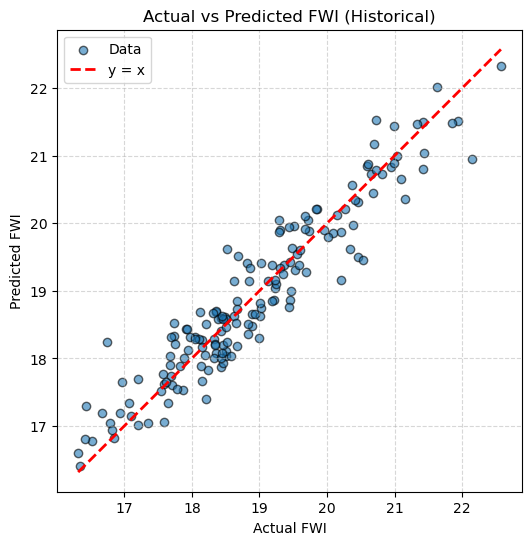

In [149]:
x = hist_df["FWI"]
y = hist_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='Data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')  # red dashed line

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (Historical)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")  # ensures equal aspect ratio

plt.show()

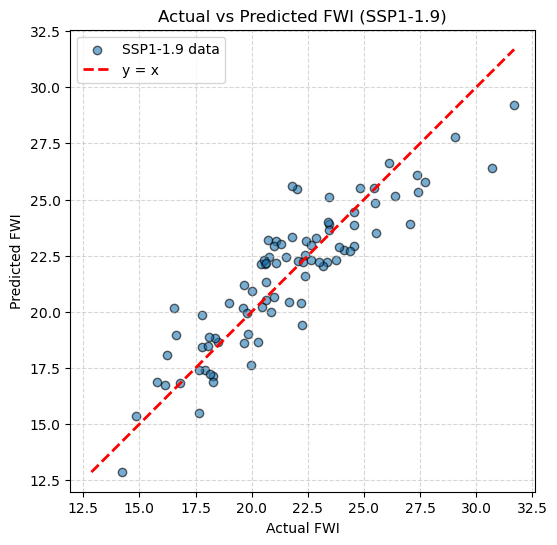

In [155]:
x = ssp119_df["FWI"]
y = ssp119_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP1-1.9 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP1-1.9)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

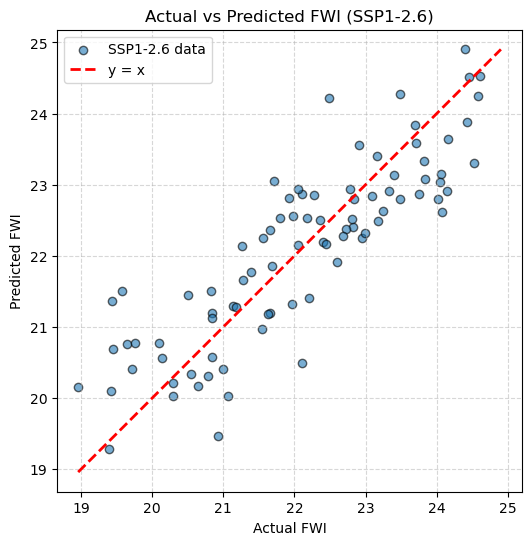

In [159]:
x = ssp126_df["FWI"]
y = ssp126_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP1-2.6 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP1-2.6)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

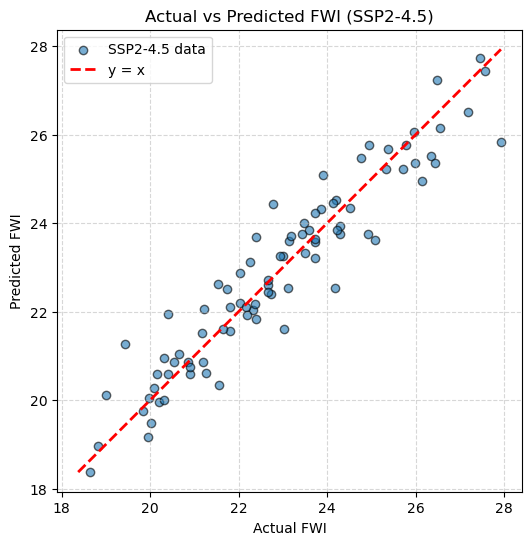

In [161]:
x = ssp245_df["FWI"]
y = ssp245_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP2-4.5 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP2-4.5)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

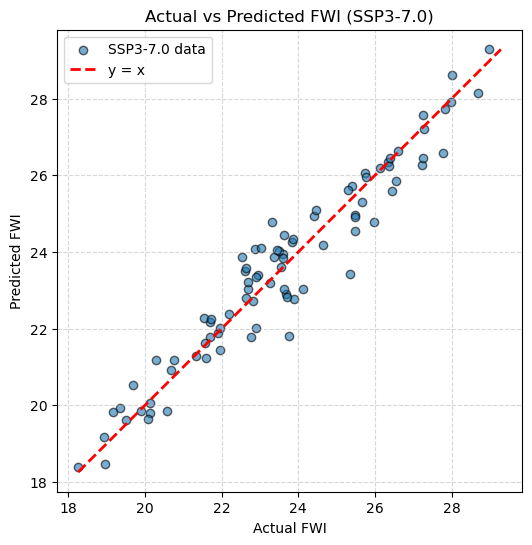

In [163]:
x = ssp370_df["FWI"]
y = ssp370_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP3-7.0 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP3-7.0)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

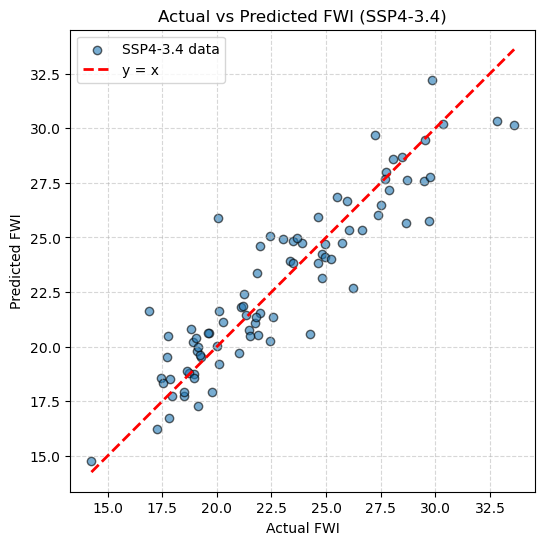

In [165]:
x = ssp434_df["FWI"]
y = ssp434_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP4-3.4 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP4-3.4)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

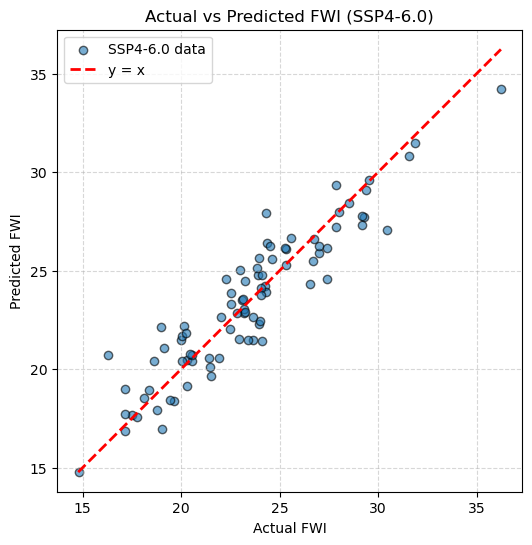

In [167]:
x = ssp460_df["FWI"]
y = ssp460_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP4-6.0 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP4-6.0)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

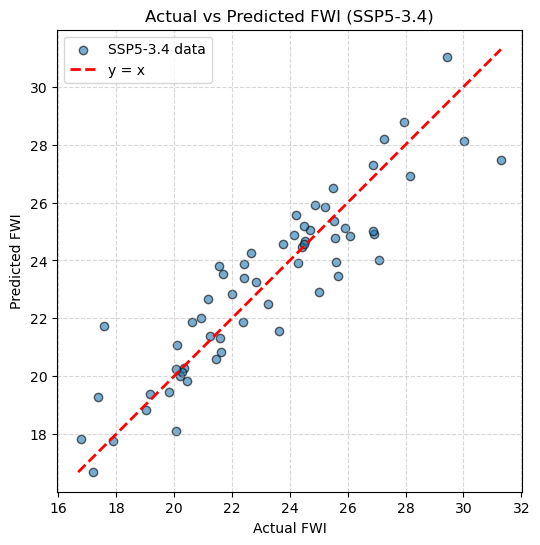

In [169]:
x = ssp534_df["FWI"]
y = ssp534_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP5-3.4 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP5-3.4)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

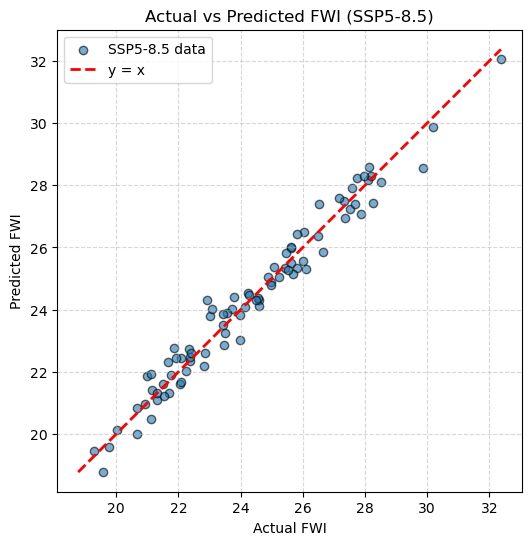

In [171]:
x = ssp585_df["FWI"]
y = ssp585_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP5-8.5 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP5-8.5)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

In [58]:
import statsmodels.formula.api as smf
from scipy.stats import zscore
# --- 1) Check that panel_df_th exists and is non-empty ---
assert 'panel_df_th' in globals(), "panel_df_th not found. Run the preprocess step first."
assert len(panel_df_th) > 0, "Empty panel_df_th after preprocessing."

# (Reminder: tasmax = °C, pr = mm/day, hurs = %, sfcWind = m/s, FWI = dimensionless)

# --- 2) Build formula with fixed effects for scenario if >= 2 unique scenarios ---
use_fe = panel_df_th['scenario'].nunique() >= 2
formula = "FWI ~ tasmax + pr + hurs + sfcWind" + (" + C(scenario)" if use_fe else "")

# --- 3) Fit OLS with robust standard errors (HC1) ---
mlr_model = smf.ols(formula, data=panel_df_th).fit(cov_type='HC1')
print("\n=== OLS (HC1 robust SE) ===")
print(mlr_model.summary())

# --- 4) Standardized (beta) coefficients for effect size comparison ---
df_std = panel_df_th.copy()
to_z = ['FWI','tasmax','pr','hurs','sfcWind']  # do not standardize categorical vars
df_std[to_z] = df_std[to_z].apply(zscore)

mlr_model_beta = smf.ols(formula, data=df_std).fit(cov_type='HC1')
print("\n=== Standardized (beta) coefficients ===")
print(mlr_model_beta.params[['tasmax','pr','hurs','sfcWind']])
print("\n(Positive beta ⇒ variable increases as FWI increases, Negative beta ⇒ inverse relationship)")

# --- 5) Optional: table of coefficients, SE, CI, p-values ---
coef_table = pd.DataFrame({
    'coef'   : mlr_model.params,
    'HC1_se' : mlr_model.bse,
    't'      : mlr_model.tvalues,
    'pvalue' : mlr_model.pvalues,
})
coef_table['CI_low']  = coef_table['coef'] - 1.96*coef_table['HC1_se']
coef_table['CI_high'] = coef_table['coef'] + 1.96*coef_table['HC1_se']
print("\n=== Coefficients table (HC1) ===")
print(coef_table.round(4))


=== OLS (HC1 robust SE) ===
                            OLS Regression Results                            
Dep. Variable:                    FWI   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     969.6
Date:                Thu, 16 Oct 2025   Prob (F-statistic):               0.00
Time:                        16:39:05   Log-Likelihood:                -1255.0
No. Observations:                 828   AIC:                             2536.
Df Residuals:                     815   BIC:                             2597.
Df Model:                          12                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [59]:
# =========================
# OLS per-scenario (HC1) + standardized betas + tidy tables
# =========================
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import zscore

# ---- 0) Settings ----
RESPONSE   = "FWI"
PREDICTORS = ["tasmax", "pr", "hurs", "sfcWind"]   # swap "hurs" -> "h2o" if you prefer

# If you want shorter scenario names, you can map them first (optional):
scenario_map = {
    "Historical to Present (1850-2015)": "Historical",
    'SSP1-1.9 ("Sustainability - Very Low Emissions")': "SSP119",
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")': "SSP126",
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")': "SSP245",
    'SSP3-7.0 ("Regional Rivalry - High Emissions")': "SSP370",
    'SSP4-3.4 ("Inequality - Intermediate Emissions")': "SSP434",
    'SSP4-6.0 ("Inequality - High Emissions")': "SSP460",
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")': "SSP534",
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")': "SSP585",
}
panel_df_th["scenario_short"] = panel_df_th["scenario"].map(scenario_map).fillna(panel_df_th["scenario"])

scenarios = list(panel_df_th["scenario_short"].unique())

# Containers for combined outputs
per_sc_models       = {}         # scenario -> fitted model (unstandardized)
per_sc_models_beta  = {}         # scenario -> fitted model on z-scored data
coef_tables         = []         # long-form rows (per scenario)
beta_tables         = []         # standardized betas (per scenario)
metrics_rows        = []         # R2 etc.

for sc in scenarios:
    df_sc = panel_df_th.loc[panel_df_th["scenario_short"] == sc, [RESPONSE] + PREDICTORS].dropna()
    if df_sc.shape[0] < len(PREDICTORS) + 2:
        # too few rows to reliably fit; skip
        print(f"Skip {sc}: not enough rows ({df_sc.shape[0]})")
        continue

    # --- 1) Unstandardized OLS with HC1 ---
    formula_sc = f"{RESPONSE} ~ " + " + ".join(PREDICTORS)  # no FE term; this is per-scenario
    model_sc = smf.ols(formula_sc, data=df_sc).fit(cov_type="HC1")
    per_sc_models[sc] = model_sc

    # --- 2) Standardized betas (z-score within scenario) ---
    df_sc_std = df_sc.copy()
    cols_to_z = [RESPONSE] + PREDICTORS
    df_sc_std[cols_to_z] = df_sc_std[cols_to_z].apply(zscore)
    model_sc_beta = smf.ols(formula_sc, data=df_sc_std).fit(cov_type="HC1")
    per_sc_models_beta[sc] = model_sc_beta

    # --- 3) Collect tidy coef table (unstandardized) ---
    ct = pd.DataFrame({
        "scenario": sc,
        "term": model_sc.params.index,
        "coef": model_sc.params.values,
        "HC1_se": model_sc.bse.values,
        "t": model_sc.tvalues.values,
        "pvalue": model_sc.pvalues.values,
    })
    ct["CI_low"]  = ct["coef"] - 1.96 * ct["HC1_se"]
    ct["CI_high"] = ct["coef"] + 1.96 * ct["HC1_se"]
    coef_tables.append(ct)

    # --- 4) Collect standardized betas (only predictors) ---
    bt = pd.Series(
        {k: v for k, v in model_sc_beta.params.items() if k in PREDICTORS},
        name=sc
    )
    beta_tables.append(bt)

    # --- 5) Metrics per scenario ---
    metrics_rows.append(pd.Series({
        "scenario": sc,
        "n": df_sc.shape[0],
        "k": len(PREDICTORS),
        "R2": model_sc.rsquared,
        "Adj_R2": model_sc.rsquared_adj,
        "F": model_sc.fvalue if np.isfinite(model_sc.fvalue) else np.nan
    }))

# ---- Combine outputs ----
coef_table_all = pd.concat(coef_tables, ignore_index=True) if coef_tables else pd.DataFrame()
beta_table     = pd.DataFrame(beta_tables) if beta_tables else pd.DataFrame()
metrics_table  = pd.DataFrame(metrics_rows).set_index("scenario").sort_index() if metrics_rows else pd.DataFrame()

# ---- Pretty prints ----
print("\n=== OLS per-scenario: coefficients (HC1) ===")
if not coef_table_all.empty:
    print(coef_table_all.round(4))
else:
    print("No results (check data filtering).")

print("\n=== Standardized (beta) coefficients by scenario ===")
if not beta_table.empty:
    print(beta_table.round(3))
else:
    print("No beta results (check data filtering).")

print("\n=== Model metrics per scenario ===")
if not metrics_table.empty:
    print(metrics_table.round(3))
else:
    print("No metrics results (check data filtering).")



=== OLS per-scenario: coefficients (HC1) ===
      scenario       term      coef   HC1_se        t  pvalue    CI_low  \
0   Historical  Intercept  149.5228  15.1692   9.8570  0.0000  119.7912   
1   Historical     tasmax    0.8114   0.2657   3.0540  0.0023    0.2907   
2   Historical         pr    1.2177   0.2691   4.5257  0.0000    0.6903   
3   Historical       hurs   -2.0748   0.1138 -18.2246  0.0000   -2.2980   
4   Historical    sfcWind    0.7029   1.3626   0.5158  0.6060   -1.9678   
5     SSP1-1.9  Intercept  216.6671  37.4216   5.7899  0.0000  143.3207   
6     SSP1-1.9     tasmax   -0.2947   0.6145  -0.4796  0.6315   -1.4992   
7     SSP1-1.9         pr    1.7806   0.5497   3.2389  0.0012    0.7031   
8     SSP1-1.9       hurs   -2.4443   0.2327 -10.5044  0.0000   -2.9003   
9     SSP1-1.9    sfcWind   -2.5664   2.2467  -1.1423  0.2533   -6.9700   
10    SSP1-2.6  Intercept  229.5725  30.4679   7.5349  0.0000  169.8554   
11    SSP1-2.6     tasmax   -0.6478   0.4170  -1.5535 

In [92]:
# === Add this import at the top ===
from statsmodels.stats.outliers_influence import variance_inflation_factor

# === Helper: safe VIF for a predictor matrix ===
def _vif_table(df_predictors: pd.DataFrame) -> pd.DataFrame:
    X = df_predictors.copy()

    # Drop zero-variance columns (VIF undefined)
    nz = X.columns[X.nunique(dropna=True) > 1]
    X = X[nz]

    # Add intercept (ignored in final output)
    X = X.assign(const=1.0)

    vif_rows = []
    cols = list(X.columns)
    for i, col in enumerate(cols):
        try:
            vif_val = variance_inflation_factor(X.values, i)
        except Exception:
            vif_val = np.nan
        vif_rows.append((col, vif_val))

    out = pd.DataFrame(vif_rows, columns=["Variable", "VIF"])
    out = out[out["Variable"] != "const"].reset_index(drop=True)
    out["Tolerance"] = 1.0 / out["VIF"]
    return out

# === Collect VIFs here ===
vif_tables = []  # rows across scenarios

for sc in scenarios:
    df_sc = panel_df_th.loc[panel_df_th["scenario_short"] == sc, [RESPONSE] + PREDICTORS].dropna()
    if df_sc.shape[0] < len(PREDICTORS) + 2:
        print(f"Skip {sc}: not enough rows ({df_sc.shape[0]})")
        continue

    # --- your existing code (fit models, etc.) ---
    formula_sc = f"{RESPONSE} ~ " + " + ".join(PREDICTORS)
    model_sc = smf.ols(formula_sc, data=df_sc).fit(cov_type="HC1")
    per_sc_models[sc] = model_sc

    df_sc_std = df_sc.copy()
    cols_to_z = [RESPONSE] + PREDICTORS
    df_sc_std[cols_to_z] = df_sc_std[cols_to_z].apply(zscore)
    model_sc_beta = smf.ols(formula_sc, data=df_sc_std).fit(cov_type="HC1")
    per_sc_models_beta[sc] = model_sc_beta

    # --- your existing tidy tables (ct, bt, metrics_rows) ---
    # ... (unchanged) ...

    # --- NEW: VIF per scenario ---
    vif_sc = _vif_table(df_sc[PREDICTORS])
    vif_sc.insert(0, "scenario", sc)
    vif_sc["n"] = df_sc.shape[0]
    vif_tables.append(vif_sc)

# === Combine VIF outputs ===
vif_table_all = pd.concat(vif_tables, ignore_index=True) if vif_tables else pd.DataFrame()

# Wide format (scenario x predictors) for quick viewing
vif_wide = (vif_table_all
            .pivot(index="scenario", columns="Variable", values="VIF")
            .reindex(sorted(vif_table_all["scenario"].unique())))

print("\n=== VIF per scenario (long) ===")
print(vif_table_all.round(3) if not vif_table_all.empty else "No VIF results.")

print("\n=== VIF per scenario (wide) ===")
print(vif_wide.round(3) if not vif_wide.empty else "No VIF results.")

# Optionally merge a quick flag into metrics table (if you want):
if not metrics_table.empty and not vif_wide.empty:
    high_vif_flag = (vif_wide > 5).any(axis=1).rename("Any_VIF_gt5")
    metrics_table = metrics_table.join(high_vif_flag, how="left")
    print("\n=== Model metrics (+ Any_VIF_gt5) ===")
    print(metrics_table.round(3))



=== VIF per scenario (long) ===
      scenario Variable    VIF  Tolerance    n
0   Historical   tasmax  2.293      0.436  165
1   Historical       pr  4.092      0.244  165
2   Historical     hurs  5.958      0.168  165
3   Historical  sfcWind  1.154      0.866  165
4     SSP1-1.9   tasmax  2.853      0.351   86
5     SSP1-1.9       pr  1.560      0.641   86
6     SSP1-1.9     hurs  4.235      0.236   86
7     SSP1-1.9  sfcWind  1.602      0.624   86
8     SSP1-2.6   tasmax  3.344      0.299   86
9     SSP1-2.6       pr  1.876      0.533   86
10    SSP1-2.6     hurs  3.556      0.281   86
11    SSP1-2.6  sfcWind  1.248      0.801   86
12    SSP2-4.5   tasmax  5.933      0.169   86
13    SSP2-4.5       pr  2.165      0.462   86
14    SSP2-4.5     hurs  7.158      0.140   86
15    SSP2-4.5  sfcWind  1.658      0.603   86
16    SSP3-7.0   tasmax  5.324      0.188   86
17    SSP3-7.0       pr  2.142      0.467   86
18    SSP3-7.0     hurs  7.986      0.125   86
19    SSP3-7.0  sfcWind  2.

In [132]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# --- Select predictors and drop missing ---
df_all = panel_df_th[[RESPONSE] + PREDICTORS].dropna().copy()

# --- Compute VIF for predictors only ---
X = df_all[PREDICTORS].assign(const=1.0)

vif_table_allssp = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_table_allssp = vif_table_allssp[vif_table_allssp["Variable"] != "const"]
vif_table_allssp["Tolerance"] = 1.0 / vif_table_allssp["VIF"]

print("\n=== VIF (all SSPs combined) ===")
print(vif_table_allssp.round(3))



=== VIF (all SSPs combined) ===
  Variable    VIF  Tolerance
0   tasmax  3.090      0.324
1       pr  1.712      0.584
2     hurs  4.690      0.213
3  sfcWind  1.535      0.651


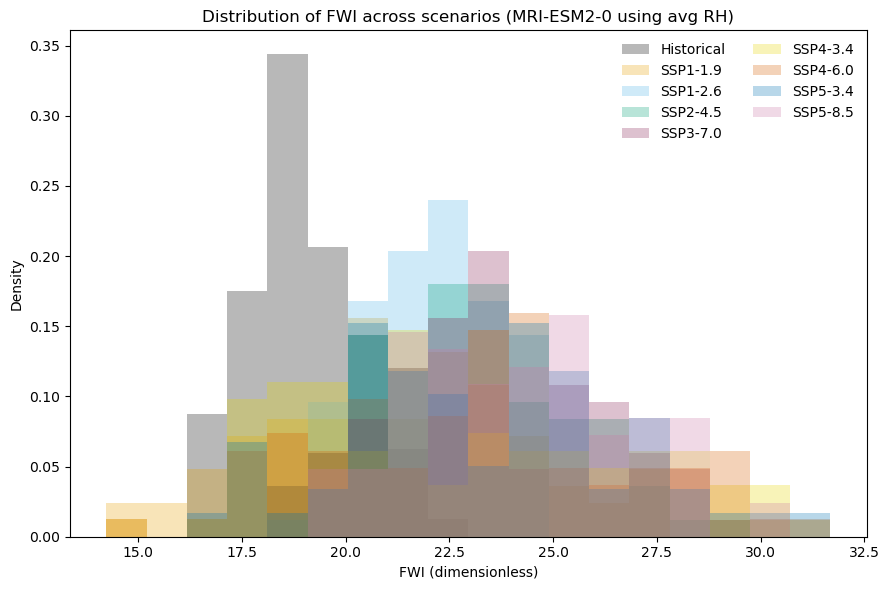

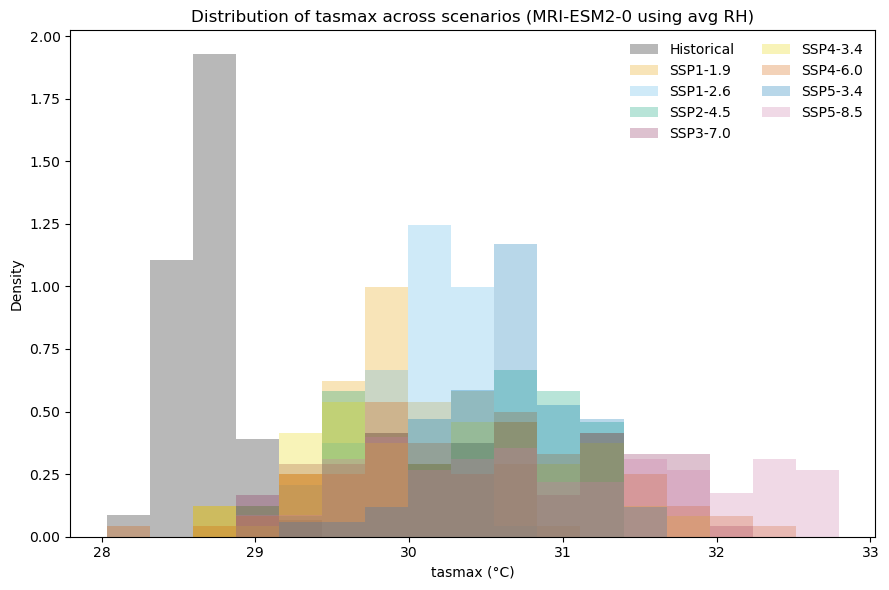

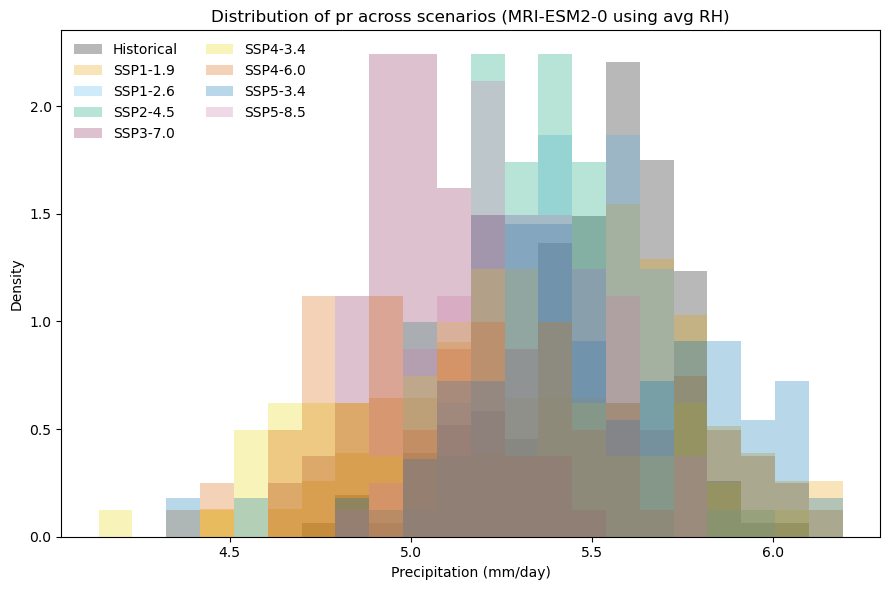

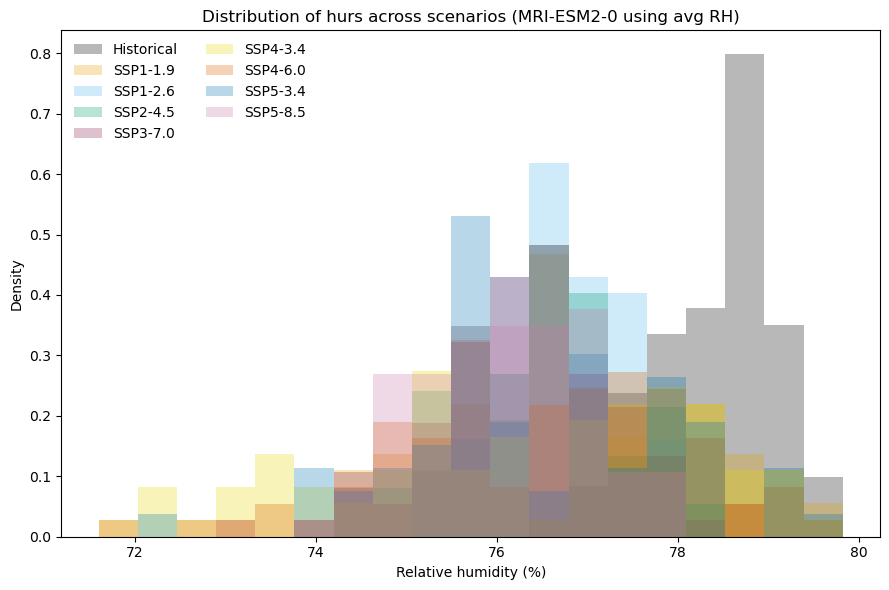

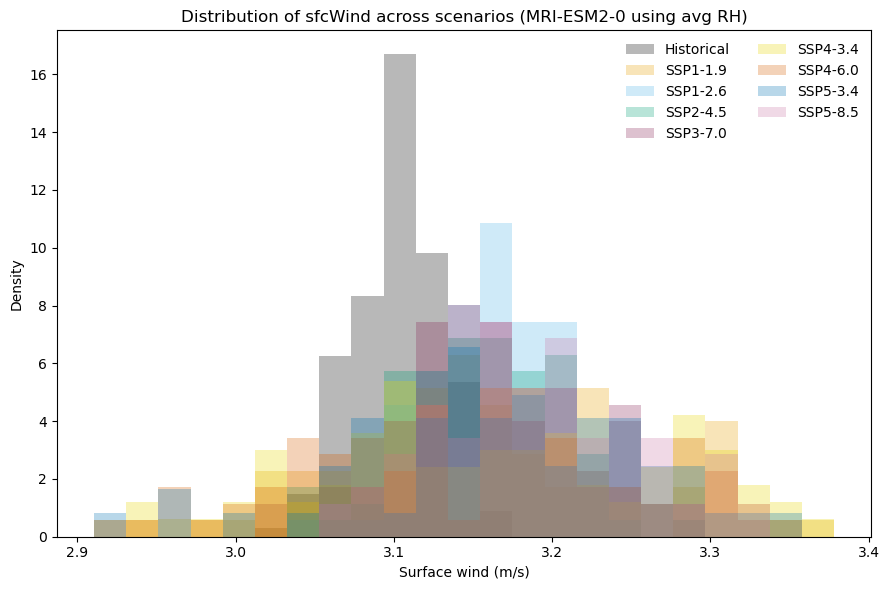

In [60]:
df = panel_df_th.copy()  # columns: time, FWI, tasmax, pr, hurs, sfcWind, scenario

# Exact labels you used (keeps a consistent legend/order)
scenario_order = [
    "Historical",
    "SSP1-1.9",
    "SSP1-2.6",
    "SSP2-4.5",
    "SSP3-7.0",
    "SSP4-3.4",
    "SSP4-6.0",
    "SSP5-3.4",
    "SSP5-8.5",
]

# Variables to plot
vars_to_plot = ["FWI", "tasmax", "pr", "hurs", "sfcWind"]

# Color-blind palette
palette = {
    "Historical": "#000000",
    "SSP1-1.9":   "#E69F00",
    "SSP1-2.6":   "#56B4E9",
    "SSP2-4.5":   "#009E73",
    "SSP3-7.0":   "#882255",
    "SSP4-3.4":   "#E6D600",
    "SSP4-6.0":   "#D55E00",
    "SSP5-3.4":   "#0072B2",
    "SSP5-8.5":   "#CC79A7",
}

# Optional: trim extreme upper tail so the bulk is visible
upper_percentile = 99.5  # set to None to disable

# Optional: plot skewed vars on log-x
logx_vars = {}

# ====== UNIT SAFETY (in case conversions weren’t applied inside prepare_*) ======
# tasmax: if median seems Kelvin (>100), convert to °C (already in celcius)
if pd.to_numeric(df["tasmax"], errors="coerce").median() > 100:
    df["tasmax"] = pd.to_numeric(df["tasmax"], errors="coerce") 

# pr: if typical values look like kg m^-2 s^-1 (e.g., < 1), convert to mm/day
# (Heuristic: if 95th percentile < 15, probably still in kg m^-2 s^-1 for Thailand annual means Now already in mm/yr)
q95 = pd.to_numeric(df["pr"], errors="coerce").quantile(0.95)
if np.isfinite(q95) and q95 < 15:  # tweak if needed
    df["pr"] = pd.to_numeric(df["pr"], errors="coerce") 

# ====== CLEAN / PREP ======
df = df[df["scenario"].isin(scenario_order)].copy()
df["scenario"] = pd.Categorical(df["scenario"], categories=scenario_order, ordered=True)

for col in vars_to_plot:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=vars_to_plot + ["scenario"])

labels_map = {
    "FWI": "FWI (dimensionless)",
    "tasmax": "tasmax (°C)",
    "pr": "Precipitation (mm/day)",
    "hurs": "Relative humidity (%)",
    "sfcWind": "Surface wind (m/s)",
}

def _common_bins(values, max_bins=120):
    edges = np.histogram_bin_edges(values, bins="fd")
    if len(edges) > max_bins:
        edges = np.linspace(edges.min(), edges.max(), max_bins)
    return edges

# ====== PLOT: one figure per variable, all scenarios overlaid ======
for var in vars_to_plot:
    pooled = df[var].to_numpy()
    if upper_percentile is not None and pooled.size:
        cap = np.nanpercentile(pooled, upper_percentile)
        pooled = pooled[pooled <= cap]

    # Build common bins from pooled data
    bin_edges = _common_bins(pooled) if pooled.size else 30

    plt.figure(figsize=(9, 6))
    for scen in scenario_order:
        vals = df.loc[df["scenario"] == scen, var].to_numpy()
        if upper_percentile is not None and vals.size:
            vals = vals[vals <= cap]
        if vals.size == 0:
            continue
        plt.hist(
            vals,
            bins=bin_edges,
            density=True,           # compare shapes regardless of sample size
            alpha=0.28,
            edgecolor="none",
            label=scen,
            color=palette.get(scen, None),
        )

    plt.xlabel(labels_map.get(var, var))
    plt.ylabel("Density")
    plt.title(f"Distribution of {var} across scenarios (MRI-ESM2-0 using avg RH)")

    if var in logx_vars and np.any(pooled > 0):
        plt.xscale("log")

    plt.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

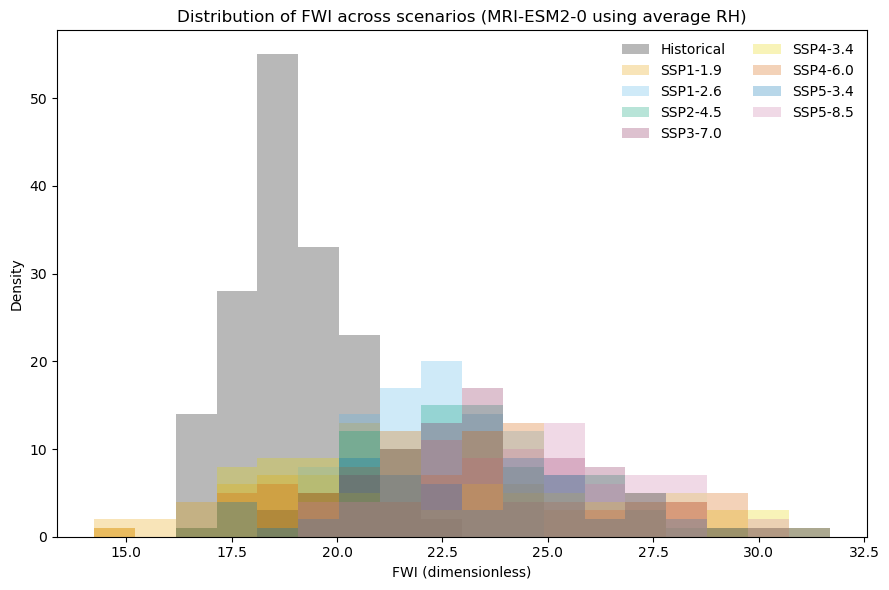

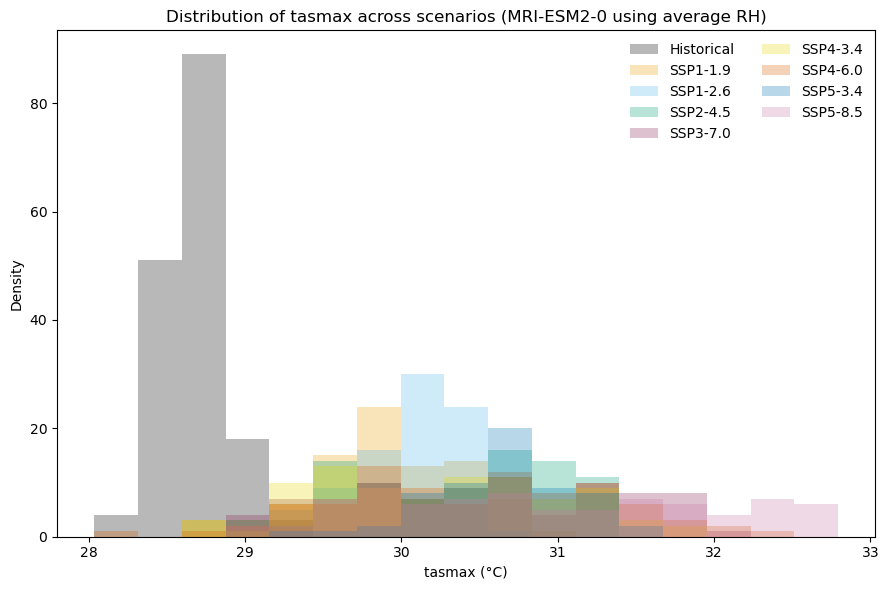

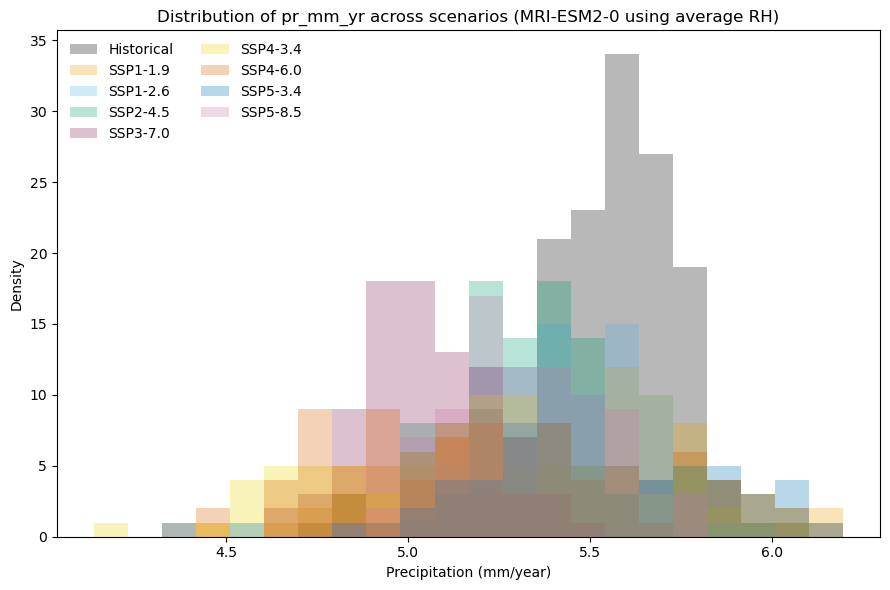

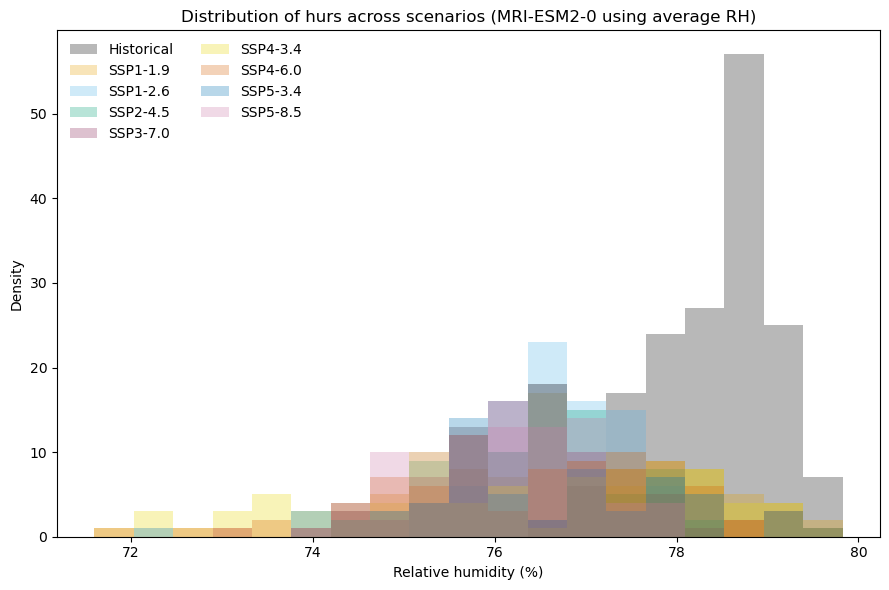

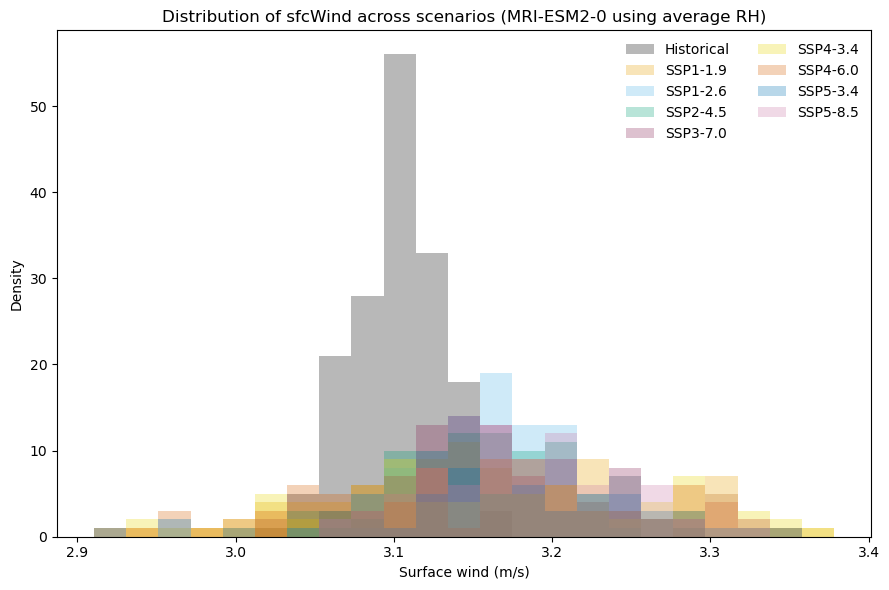

In [61]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== CONFIG =====================
df = panel_df_th.copy()   # or panel_df_th, etc.

# If you know the exact pr unit coming in, set this:
#   "auto" | "kg m-2 s-1" | "mm/day" | "mm/yr"
PR_UNIT_IN = "mm/yr"

DAYS_PER_YEAR = 365.2422
SECONDS_PER_DAY = 86400.0
SECONDS_PER_YEAR = SECONDS_PER_DAY * DAYS_PER_YEAR

# Variables to plot (we'll replace 'pr' with 'pr_mm_yr' after conversion)
vars_to_plot = ["FWI", "tasmax", "pr_mm_yr", "hurs", "sfcWind"]

palette_all = {
    "Historical": "#000000",
    "SSP1-1.9":   "#E69F00",
    "SSP1-2.6":   "#56B4E9",
    "SSP2-4.5":   "#009E73",
    "SSP3-7.0":   "#882255",
    "SSP4-3.4":   "#E6D600",
    "SSP4-6.0":   "#D55E00",
    "SSP5-3.4":   "#0072B2",
    "SSP5-8.5":   "#CC79A7",
}

labels_map = {
    "FWI": "FWI (dimensionless)",
    "tasmax": "tasmax (°C)",
    "pr_mm_yr": "Precipitation (mm/year)",
    "hurs": "Relative humidity (%)",
    "sfcWind": "Surface wind (m/s)",
}

upper_pct = 99.5          # None to disable tail trim
logx_vars = set()         # e.g., {"pr_mm_yr"} if you want log scale

# ===================== HELPERS =====================
def canonical_scenario(s):
    if pd.isna(s): return s
    s = str(s)
    if "Historical" in s or "1850-2015" in s:
        return "Historical"
    m = re.search(r"SSP[1-5]-\d(?:\.\d)?", s)
    return m.group(0) if m else s.strip()

def pr_to_mm_per_year(series, assume="auto"):
    x = pd.to_numeric(series, errors="coerce").astype(float)
    if assume == "kg m-2 s-1":
        return x * SECONDS_PER_YEAR
    elif assume == "mm/day":
        return x * DAYS_PER_YEAR
    elif assume == "mm/yr":
        return x
    else:
        # Heuristic: if the upper tail is < 1, it's almost certainly kg m-2 s-1.
        # (Typical mm/day annual means are several mm/day in Thailand)
        q95 = np.nanpercentile(x, 95)
        if np.isfinite(q95) and q95 < 1.0:
            return x * SECONDS_PER_YEAR
        else:
            return x * DAYS_PER_YEAR

def common_bins(values, max_bins=120):
    edges = np.histogram_bin_edges(values, bins="fd")
    if len(edges) > max_bins:
        edges = np.linspace(edges.min(), edges.max(), max_bins)
    return edges

# ===================== PREP =====================
scenario_col = "scenario_short" if "scenario_short" in df.columns else "scenario"
df["scenario"] = df[scenario_col].apply(canonical_scenario)

canonical_order = ["Historical","SSP1-1.9","SSP1-2.6","SSP2-4.5","SSP3-7.0","SSP4-3.4","SSP4-6.0","SSP5-3.4","SSP5-8.5"]
present = [s for s in canonical_order if s in set(df["scenario"].dropna().unique())]
df = df[df["scenario"].isin(present)].copy()
df["scenario"] = pd.Categorical(df["scenario"], categories=present, ordered=True)

# Units: tasmax K -> °C if needed (guard in case your builder didn't convert)
if pd.to_numeric(df["tasmax"], errors="coerce").median() > 100:
    df["tasmax"] = pd.to_numeric(df["tasmax"], errors="coerce") - 273.15

# Convert precipitation to mm/year
df["pr_mm_yr"] = pr_to_mm_per_year(df["pr"], assume=PR_UNIT_IN)
# Remove tiny negatives (numerical noise)
df["pr_mm_yr"] = df["pr_mm_yr"].clip(lower=0)

# Ensure numeric + drop NaNs for plotted vars
for col in vars_to_plot:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=vars_to_plot + ["scenario"])

# Color map for only the scenarios present
palette = {k: palette_all[k] for k in present if k in palette_all}

# ===================== PLOT =====================
for var in vars_to_plot:
    pooled = df[var].to_numpy()
    if pooled.size == 0:
        continue
    if upper_pct is not None:
        cap = np.nanpercentile(pooled, upper_pct)
        pooled = pooled[pooled <= cap]
    bins = common_bins(pooled)

    plt.figure(figsize=(9,6))
    for scen in present:
        vals = df.loc[df["scenario"] == scen, var].to_numpy()
        if vals.size == 0:
            continue
        if upper_pct is not None:
            vals = vals[vals <= cap]
        plt.hist(vals, bins=bins, alpha=0.28, label=scen, color=palette.get(scen))
    plt.xlabel(labels_map.get(var, var))
    plt.ylabel("Density")
    plt.title(f"Distribution of {var} across scenarios (MRI-ESM2-0 using average RH)")
    if var in logx_vars and np.any(pooled > 0):
        plt.xscale("log")
    plt.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()


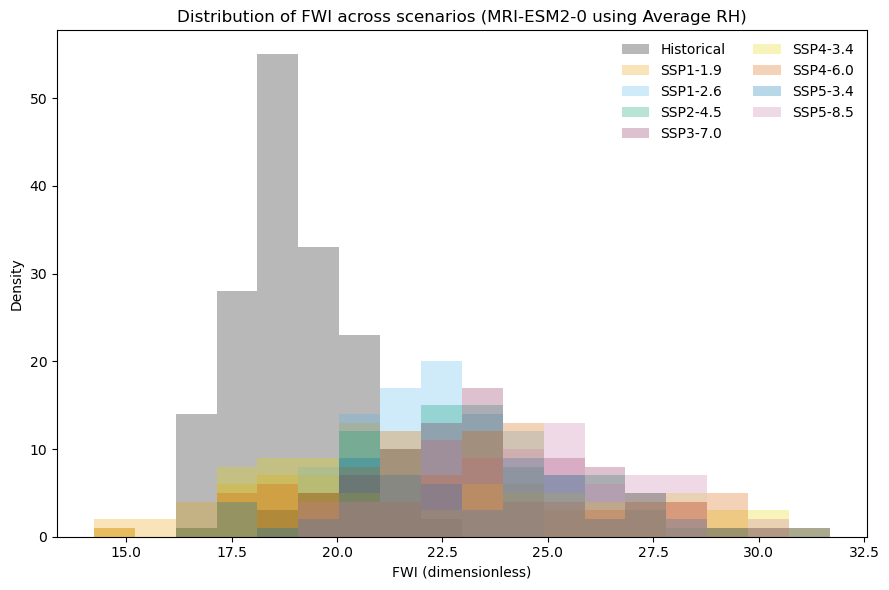

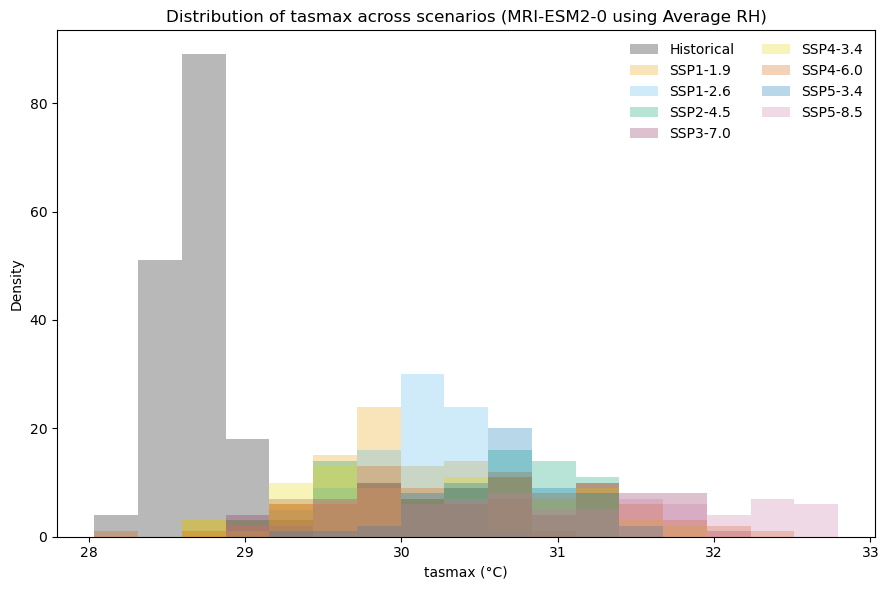

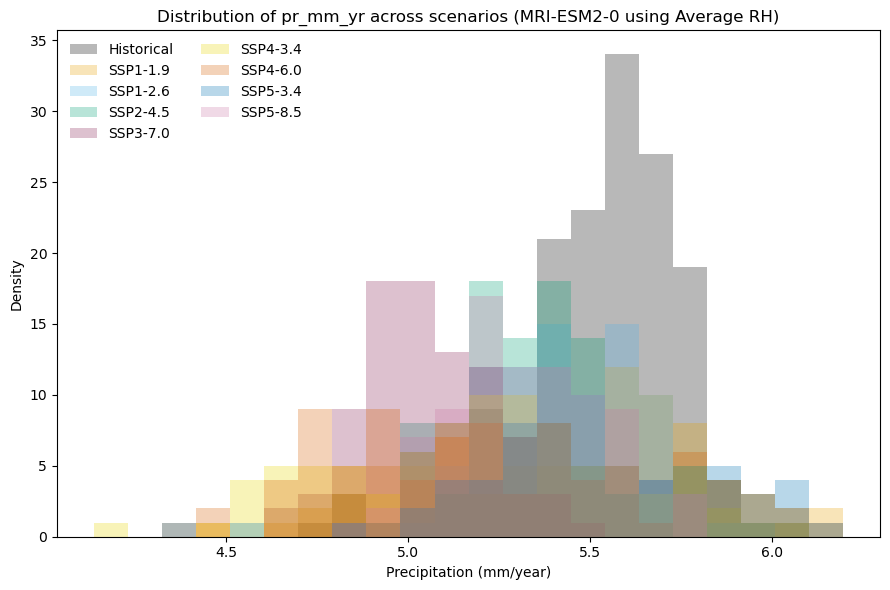

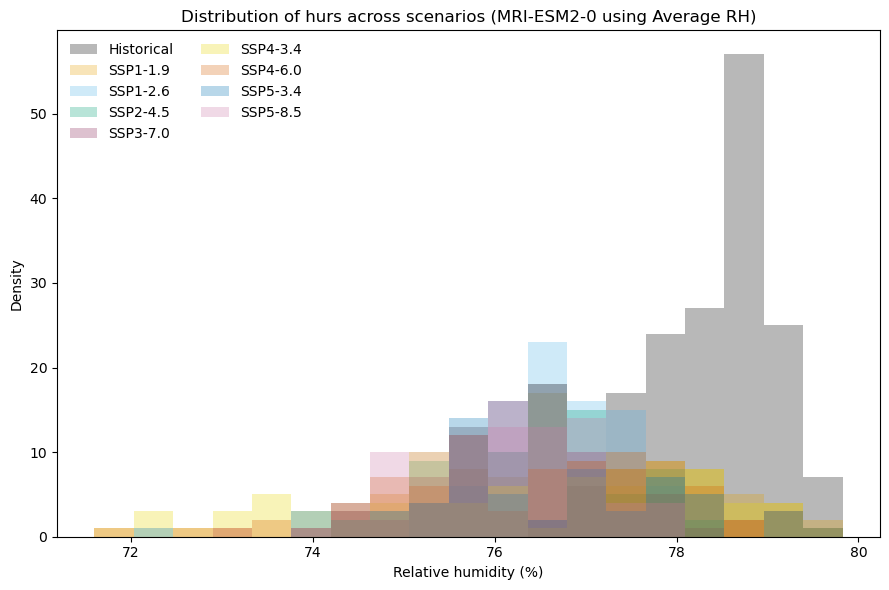

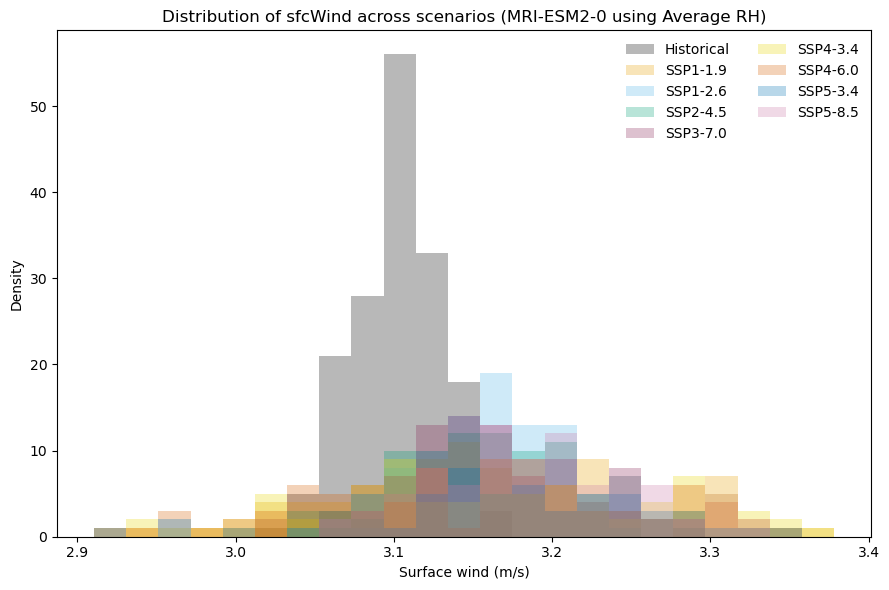

In [62]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===================== CONFIG =====================
df = panel_df_th.copy()   # or panel_df_th, etc.

# If you know the exact pr unit coming in, set this:
#   "auto" | "kg m-2 s-1" | "mm/day" | "mm/yr"
PR_UNIT_IN = "mm/yr"

DAYS_PER_YEAR = 365.2422
SECONDS_PER_DAY = 86400.0
SECONDS_PER_YEAR = SECONDS_PER_DAY * DAYS_PER_YEAR

# Variables to plot (we'll replace 'pr' with 'pr_mm_yr' after conversion)
vars_to_plot = ["FWI", "tasmax", "pr_mm_yr", "hurs", "sfcWind"]

palette_all = {
    "Historical": "#000000",
    "SSP1-1.9":   "#E69F00",
    "SSP1-2.6":   "#56B4E9",
    "SSP2-4.5":   "#009E73",
    "SSP3-7.0":   "#882255",
    "SSP4-3.4":   "#E6D600",
    "SSP4-6.0":   "#D55E00",
    "SSP5-3.4":   "#0072B2",
    "SSP5-8.5":   "#CC79A7",
}

labels_map = {
    "FWI": "FWI (dimensionless)",
    "tasmax": "tasmax (°C)",
    "pr_mm_yr": "Precipitation (mm/year)",
    "hurs": "Relative humidity (%)",
    "sfcWind": "Surface wind (m/s)",
}

upper_pct = 99.5          # None to disable tail trim
logx_vars = set()         # e.g., {"pr_mm_yr"} if you want log scale

# ---- Saving options ----
OUTPUT_DIR = Path("fig_distros_MRI_ESM2_0_Avg")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FORMATS = ["png", "pdf"]   # add "svg" if you like
DPI = 200
TRANSPARENT = False

# ===================== HELPERS =====================
def canonical_scenario(s):
    if pd.isna(s): return s
    s = str(s)
    if "Historical" in s or "1850-2015" in s:
        return "Historical"
    m = re.search(r"SSP[1-5]-\d(?:\.\d)?", s)
    return m.group(0) if m else s.strip()

def pr_to_mm_per_year(series, assume="auto"):
    x = pd.to_numeric(series, errors="coerce").astype(float)
    if assume == "kg m-2 s-1":
        return x * SECONDS_PER_YEAR
    elif assume == "mm/day":
        return x * DAYS_PER_YEAR
    elif assume == "mm/yr":
        return x
    else:
        # Heuristic
        q95 = np.nanpercentile(x, 95)
        if np.isfinite(q95) and q95 < 1.0:
            return x * SECONDS_PER_YEAR
        else:
            return x * DAYS_PER_YEAR

def common_bins(values, max_bins=120):
    edges = np.histogram_bin_edges(values, bins="fd")
    if len(edges) > max_bins:
        edges = np.linspace(edges.min(), edges.max(), max_bins)
    return edges

# ===================== PREP =====================
scenario_col = "scenario_short" if "scenario_short" in df.columns else "scenario"
df["scenario"] = df[scenario_col].apply(canonical_scenario)

canonical_order = ["Historical","SSP1-1.9","SSP1-2.6","SSP2-4.5","SSP3-7.0","SSP4-3.4","SSP4-6.0","SSP5-3.4","SSP5-8.5"]
present = [s for s in canonical_order if s in set(df["scenario"].dropna().unique())]
df = df[df["scenario"].isin(present)].copy()
df["scenario"] = pd.Categorical(df["scenario"], categories=present, ordered=True)

# Units: tasmax K -> °C if needed
if pd.to_numeric(df["tasmax"], errors="coerce").median() > 100:
    df["tasmax"] = pd.to_numeric(df["tasmax"], errors="coerce") - 273.15

# Convert precipitation to mm/year
df["pr_mm_yr"] = pr_to_mm_per_year(df["pr"], assume=PR_UNIT_IN)
df["pr_mm_yr"] = df["pr_mm_yr"].clip(lower=0)

# Ensure numeric + drop NaNs for plotted vars
for col in vars_to_plot:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=vars_to_plot + ["scenario"])

# Color map for only the scenarios present
palette = {k: palette_all[k] for k in present if k in palette_all}

# ===================== PLOT & SAVE =====================
for var in vars_to_plot:
    pooled = df[var].to_numpy()
    if pooled.size == 0:
        continue
    if upper_pct is not None:
        cap = np.nanpercentile(pooled, upper_pct)
        pooled = pooled[pooled <= cap]
    bins = common_bins(pooled)

    fig, ax = plt.subplots(figsize=(9, 6))
    for scen in present:
        vals = df.loc[df["scenario"] == scen, var].to_numpy()
        if vals.size == 0:
            continue
        if upper_pct is not None:
            vals = vals[vals <= cap]
        ax.hist(vals, bins=bins, alpha=0.28, label=scen, color=palette.get(scen))  # density defaults to False

    ax.set_xlabel(labels_map.get(var, var))
    ax.set_ylabel("Density")   # kept exactly as in your code
    ax.set_title(f"Distribution of {var} across scenarios (MRI-ESM2-0 using Average RH)")
    if var in logx_vars and np.any(pooled > 0):
        ax.set_xscale("log")
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()

    # ---- Save to files ----
    base = OUTPUT_DIR / f"dist_{var}"
    for ext in SAVE_FORMATS:
        fig.savefig(f"{base}.{ext}", dpi=DPI, transparent=TRANSPARENT, bbox_inches="tight")

    plt.show()
    plt.close(fig)


In [63]:
# ========= OVERLAID HISTOGRAMS: STEP + HATCH =========
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===================== CONFIG =====================
df = panel_df_th.copy()   # <- your DataFrame

#   "auto" | "kg m-2 s-1" | "mm/day" | "mm/yr"
PR_UNIT_IN = "mm/yr"

DAYS_PER_YEAR = 365.2422
SECONDS_PER_DAY = 86400.0
SECONDS_PER_YEAR = SECONDS_PER_DAY * DAYS_PER_YEAR

vars_to_plot = ["FWI", "tasmax", "pr_mm_yr", "hurs", "sfcWind"]

palette_all = {
    "Historical": "#000000",
    "SSP1-1.9":   "#E69F00",
    "SSP1-2.6":   "#56B4E9",
    "SSP2-4.5":   "#009E73",
    "SSP3-7.0":   "#882255",
    "SSP4-3.4":   "#E6D600",
    "SSP4-6.0":   "#D55E00",
    "SSP5-3.4":   "#0072B2",
    "SSP5-8.5":   "#CC79A7",
}

labels_map = {
    "FWI": "FWI (dimensionless)",
    "tasmax": "tasmax (°C)",
    "pr_mm_yr": "Precipitation (mm/year)",
    "hurs": "Relative humidity (%)",
    "sfcWind": "Surface wind (m/s)",
}

upper_pct = 99.5
logx_vars = set()         # e.g., {"pr_mm_yr"}

# ---- Saving options ----
OUTPUT_DIR = Path("fig_distros_OVERLAID_newstyle")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FORMATS = ["png", "pdf"]
DPI = 200
TRANSPARENT = False

# ===================== STYLE MAPS =====================
hatch_map = {
    "Historical": "",
    "SSP1-1.9":  "//",
    "SSP1-2.6":  "\\\\",
    "SSP2-4.5":  "xx",
    "SSP3-7.0":  "..",
    "SSP4-3.4":  "++",
    "SSP4-6.0":  "**",
    "SSP5-3.4":  "oo",
    "SSP5-8.5":  "--",
}

# IMPORTANT: use only string linestyles to avoid ValueError inside Axes.hist
line_map_str = {
    "Historical": "solid",
    "SSP1-1.9":  "dashed",
    "SSP1-2.6":  "dotted",
    "SSP2-4.5":  "dashdot",
    "SSP3-7.0":  "dashed",
    "SSP4-3.4":  "dotted",
    "SSP4-6.0":  "dashdot",
    "SSP5-3.4":  "dashed",
    "SSP5-8.5":  "dotted",
}

def _safe_linestyle(scen):
    ls = line_map_str.get(scen, "solid")
    # Matplotlib’s hist will cycle/np.atleast_1d this—keep it a plain string.
    return ls

# ===================== HELPERS =====================
def canonical_scenario(s):
    if pd.isna(s): return s
    s = str(s)
    if "Historical" in s or "1850-2015" in s:
        return "Historical"
    m = re.search(r"SSP[1-5]-\d(?:\.\d)?", s)
    return m.group(0) if m else s.strip()

def pr_to_mm_per_year(series, assume="auto"):
    x = pd.to_numeric(series, errors="coerce").astype(float)
    if assume == "kg m-2 s-1":
        return x * SECONDS_PER_YEAR
    elif assume == "mm/day":
        return x * DAYS_PER_YEAR
    elif assume == "mm/yr":
        return x
    else:
        q95 = np.nanpercentile(x, 95)
        if np.isfinite(q95) and q95 < 1.0:
            return x * SECONDS_PER_YEAR
        else:
            return x * DAYS_PER_YEAR

def common_bins(values, max_bins=120):
    edges = np.histogram_bin_edges(values, bins="fd")
    if len(edges) > max_bins:
        edges = np.linspace(edges.min(), edges.max(), max_bins)
    return edges

# ===================== PREP =====================
scenario_col = "scenario_short" if "scenario_short" in df.columns else "scenario"
df["scenario"] = df[scenario_col].apply(canonical_scenario)

canonical_order = ["Historical","SSP1-1.9","SSP1-2.6","SSP2-4.5","SSP3-7.0","SSP4-3.4","SSP4-6.0","SSP5-3.4","SSP5-8.5"]
present = [s for s in canonical_order if s in set(df["scenario"].dropna().unique())]
df = df[df["scenario"].isin(present)].copy()
df["scenario"] = pd.Categorical(df["scenario"], categories=present, ordered=True)

# Units: tasmax K -> °C if needed
if pd.to_numeric(df["tasmax"], errors="coerce").median() > 100:
    df["tasmax"] = pd.to_numeric(df["tasmax"], errors="coerce") - 273.15

# Convert precipitation to mm/year
df["pr_mm_yr"] = pr_to_mm_per_year(df["pr"], assume=PR_UNIT_IN).clip(lower=0)

# Ensure numeric + drop NaNs
for col in vars_to_plot:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=vars_to_plot + ["scenario"])

# Color map limited to present scenarios
palette = {k: palette_all[k] for k in present if k in palette_all}

# ===================== PLOT & SAVE =====================
from matplotlib.lines import Line2D

for var in vars_to_plot:
    pooled = df[var].to_numpy()
    if pooled.size == 0:
        continue
    if upper_pct is not None:
        cap = np.nanpercentile(pooled, upper_pct)
        pooled = pooled[pooled <= cap]
    bins = common_bins(pooled)

    fig, ax = plt.subplots(figsize=(9, 6))

    # Faint filled bars with hatches
    for scen in present:
        vals = df.loc[df["scenario"] == scen, var].to_numpy()
        if vals.size == 0:
            continue
        if upper_pct is not None:
            vals = vals[vals <= cap]
        n, edges, patches = ax.hist(
            vals, bins=bins, density=True, alpha=0.18,
            label=None, color=palette.get(scen), edgecolor="none"
        )
        for p in patches:
            p.set_hatch(hatch_map.get(scen, ""))

    # Step outlines on top (string linestyles only)
    for scen in present:
        vals = df.loc[df["scenario"] == scen, var].to_numpy()
        if vals.size == 0:
            continue
        if upper_pct is not None:
            vals = vals[vals <= cap]
        ax.hist(
            vals, bins=bins, density=True, histtype="step",
            linewidth=2.0, color=palette.get(scen),
            linestyle=_safe_linestyle(scen)
        )

    ax.set_xlabel(labels_map.get(var, var))
    ax.set_ylabel("Density")
    ax.set_title(f"Distribution of {var} across scenarios — Overlaid")
    if var in logx_vars and np.any(pooled > 0):
        ax.set_xscale("log")

    legend_elems = [Line2D([0],[0],
                           color=palette.get(s), linestyle=_safe_linestyle(s),
                           linewidth=2.0, label=s)
                    for s in present]
    ax.legend(handles=legend_elems, frameon=False, ncol=2)
    fig.tight_layout()

    base = OUTPUT_DIR / f"dist_{var}_overlaid"
    for ext in SAVE_FORMATS:
        fig.savefig(f"{base}.{ext}", dpi=DPI, transparent=TRANSPARENT, bbox_inches="tight")
    plt.close(fig)


In [64]:
# ========= OVERLAID HISTOGRAMS: STEP + HATCH (NORMALIZED + OPTIONAL SCALING) =========
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# ===================== CONFIG =====================
df = panel_df_th.copy()   # <- your DataFrame

# Precipitation unit: "auto" | "kg m-2 s-1" | "mm/day" | "mm/yr"
PR_UNIT_IN = "mm/yr"

DAYS_PER_YEAR = 365.2422
SECONDS_PER_DAY = 86400.0
SECONDS_PER_YEAR = SECONDS_PER_DAY * DAYS_PER_YEAR

vars_to_plot = ["FWI", "tasmax", "pr_mm_yr", "hurs", "sfcWind"]

palette_all = {
    "Historical": "#000000",
    "SSP1-1.9":   "#E69F00",
    "SSP1-2.6":   "#56B4E9",
    "SSP2-4.5":   "#009E73",
    "SSP3-7.0":   "#882255",
    "SSP4-3.4":   "#E6D600",
    "SSP4-6.0":   "#D55E00",
    "SSP5-3.4":   "#0072B2",
    "SSP5-8.5":   "#CC79A7",
}

labels_map = {
    "FWI": "FWI (dimensionless)",
    "tasmax": "tasmax (°C)",
    "pr_mm_yr": "Precipitation (mm/year)",
    "hurs": "Relative humidity (%)",
    "sfcWind": "Surface wind (m/s)",
}

upper_pct = 99.5            # uniform tail trim across scenarios (set None to disable)
logx_vars = set()           # e.g., {"pr_mm_yr"} to plot on log-x (for raw/unscaled)
pretransform_log10_vars = set()  # e.g., {"pr_mm_yr"} to log10 before scaling/binning

# ---- Normalization & Scaling ----
# normalize_mode: "pdf" (area=1; y can exceed 1) | "fraction" (bar heights sum to 1; y<=1)
normalize_mode = "pdf"
# scale_mode: "none" | "z" | "robust_z" | "minmax"
scale_mode = "none"  # use "robust_z" to compare variables on the same scale

# ---- Saving options ----
OUTPUT_DIR = Path("fig_distros_OVERLAID_normalized")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FORMATS = ["png", "pdf"]
DPI = 200
TRANSPARENT = False

# ===================== STYLE MAPS =====================
hatch_map = {
    "Historical": "",
    "SSP1-1.9":  "//",
    "SSP1-2.6":  "\\\\",
    "SSP2-4.5":  "xx",
    "SSP3-7.0":  "..",
    "SSP4-3.4":  "++",
    "SSP4-6.0":  "**",
    "SSP5-3.4":  "oo",
    "SSP5-8.5":  "--",
}

line_map_str = {
    "Historical": "solid",
    "SSP1-1.9":  "dashed",
    "SSP1-2.6":  "dotted",
    "SSP2-4.5":  "dashdot",
    "SSP3-7.0":  "dashed",
    "SSP4-3.4":  "dotted",
    "SSP4-6.0":  "dashdot",
    "SSP5-3.4":  "dashed",
    "SSP5-8.5":  "dotted",
}

def _safe_linestyle(scen):
    return line_map_str.get(scen, "solid")

# ===================== HELPERS =====================
def canonical_scenario(s):
    if pd.isna(s): return s
    s = str(s)
    if "Historical" in s or "1850-2015" in s:
        return "Historical"
    m = re.search(r"SSP[1-5]-\d(?:\.\d)?", s)
    return m.group(0) if m else s.strip()

def pr_to_mm_per_year(series, assume="auto"):
    x = pd.to_numeric(series, errors="coerce").astype(float)
    if assume == "kg m-2 s-1":
        return x * SECONDS_PER_YEAR
    elif assume == "mm/day":
        return x * DAYS_PER_YEAR
    elif assume == "mm/yr":
        return x
    else:
        q95 = np.nanpercentile(x, 95)
        return x * SECONDS_PER_YEAR if (np.isfinite(q95) and q95 < 1.0) else x * DAYS_PER_YEAR

def common_bins(values, max_bins=120):
    edges = np.histogram_bin_edges(values, bins="fd")
    if len(edges) > max_bins:
        edges = np.linspace(edges.min(), edges.max(), max_bins)
    return edges

def pretransform(values: np.ndarray, varname: str):
    if varname in pretransform_log10_vars:
        return np.log10(values, where=(values > 0), out=np.full_like(values, np.nan))
    return values

def fit_scaler(values: np.ndarray, mode: str):
    v = values[np.isfinite(values)]
    if mode == "none":
        return lambda x: x, ""
    if mode == "z":
        mu = np.nanmean(v); sd = np.nanstd(v, ddof=0); sd = sd if sd > 0 else np.nan
        return (lambda x: (x - mu) / sd if np.isfinite(sd) else x*0), " [z-score]"
    if mode == "robust_z":
        med = np.nanmedian(v); q1, q3 = np.nanpercentile(v, [25, 75]); iqr = q3 - q1
        sd_r = (iqr / 1.349) if iqr > 0 else np.nan
        return (lambda x: (x - med) / sd_r if np.isfinite(sd_r) else x*0), " [robust z]"
    if mode == "minmax":
        mn, mx = np.nanmin(v), np.nanmax(v); rng = (mx - mn) if mx > mn else np.nan
        return (lambda x: (x - mn) / rng if np.isfinite(rng) else x*0), " [min–max]"
    raise ValueError("Unknown scale_mode")

# ===================== PREP =====================
scenario_col = "scenario_short" if "scenario_short" in df.columns else "scenario"
df["scenario"] = df[scenario_col].apply(canonical_scenario)

canonical_order = ["Historical","SSP1-1.9","SSP1-2.6","SSP2-4.5","SSP3-7.0","SSP4-3.4","SSP4-6.0","SSP5-3.4","SSP5-8.5"]
present = [s for s in canonical_order if s in set(df["scenario"].dropna().unique())]
df = df[df["scenario"].isin(present)].copy()
df["scenario"] = pd.Categorical(df["scenario"], categories=present, ordered=True)

# Units: tasmax K -> °C if needed
if pd.to_numeric(df["tasmax"], errors="coerce").median() > 100:
    df["tasmax"] = pd.to_numeric(df["tasmax"], errors="coerce") - 273.15

# Convert precipitation to mm/year
df["pr_mm_yr"] = pr_to_mm_per_year(df["pr"], assume=PR_UNIT_IN).clip(lower=0)

# Ensure numeric + drop NaNs
for col in vars_to_plot:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=vars_to_plot + ["scenario"])

# Color map limited to present scenarios
palette = {k: palette_all[k] for k in present if k in palette_all}

# ===================== PLOT & SAVE =====================
for var in vars_to_plot:
    # pooled raw for uniform trimming
    pooled_raw = df[var].to_numpy()
    pooled_raw = pooled_raw[np.isfinite(pooled_raw)]
    if pooled_raw.size == 0:
        continue

    cap = np.nanpercentile(pooled_raw, upper_pct) if upper_pct is not None else np.inf

    # pooled trimmed + pre-transformed (for fitting scaler and building bins)
    pooled_trim = pooled_raw[pooled_raw <= cap]
    pooled_trim = pretransform(pooled_trim, var)

    # Fit scaler based on pooled data
    transform, label_suffix = fit_scaler(pooled_trim, scale_mode)

    # Build pooled scaled values for binning
    pooled_scaled = []
    per_scen_scaled = []
    for scen in present:
        vals = df.loc[df["scenario"] == scen, var].to_numpy()
        vals = vals[np.isfinite(vals)]
        vals = vals[vals <= cap]
        vals = pretransform(vals, var)
        vals = transform(vals)
        per_scen_scaled.append(vals)
        if vals.size:
            pooled_scaled.append(vals)
    if not pooled_scaled:
        continue
    pooled_scaled = np.concatenate(pooled_scaled, axis=0)

    bins = common_bins(pooled_scaled)

    fig, ax = plt.subplots(figsize=(9, 6))

    # ---- Filled bars with hatches (normalized) ----
    for scen, vals_scaled in zip(present, per_scen_scaled):
        if vals_scaled.size == 0:
            continue
        if normalize_mode == "pdf":
            _, _, patches = ax.hist(
                vals_scaled, bins=bins, density=True, alpha=0.18,
                label=None, color=palette.get(scen), edgecolor="none", zorder=1
            )
        elif normalize_mode == "fraction":
            w = np.ones_like(vals_scaled) / vals_scaled.size
            _, _, patches = ax.hist(
                vals_scaled, bins=bins, weights=w, alpha=0.18,
                label=None, color=palette.get(scen), edgecolor="none", zorder=1
            )
        else:
            raise ValueError("normalize_mode must be 'pdf' or 'fraction'")
        for p in patches:
            p.set_hatch(hatch_map.get(scen, ""))

    # ---- Step outlines on top ----
    for scen, vals_scaled in zip(present, per_scen_scaled):
        if vals_scaled.size == 0:
            continue
        if normalize_mode == "pdf":
            ax.hist(
                vals_scaled, bins=bins, density=True, histtype="step",
                linewidth=2.0, color=palette.get(scen),
                linestyle=_safe_linestyle(scen), zorder=2
            )
        else:
            w = np.ones_like(vals_scaled) / vals_scaled.size
            ax.hist(
                vals_scaled, bins=bins, weights=w, histtype="step",
                linewidth=2.0, color=palette.get(scen),
                linestyle=_safe_linestyle(scen), zorder=2
            )

    # Labels & title
    ylab = "Probability density" if normalize_mode == "pdf" else "Fraction of samples"
    prelog = " [log10 pretransform]" if var in pretransform_log10_vars else ""
    ax.set_xlabel(f"{labels_map.get(var, var)}{prelog}{label_suffix}")
    ax.set_ylabel(ylab)
    ax.set_title(f"Distribution of {var} across scenarios — Overlaid (normalized)")

    # Log x-axis only makes sense if you did NOT scale; use pretransform_log10_vars instead
    if scale_mode == "none" and (var in logx_vars) and np.any(np.isfinite(pooled_trim) & (pooled_trim > 0)):
        ax.set_xscale("log")

    legend_elems = [Line2D([0],[0],
                           color=palette.get(s), linestyle=_safe_linestyle(s),
                           linewidth=2.0, label=s)
                    for s in present]
    ax.legend(handles=legend_elems, frameon=False, ncol=2)
    fig.tight_layout()

    base = OUTPUT_DIR / f"dist_{var}_overlaid_norm-{normalize_mode}_scale-{scale_mode}"
    for ext in SAVE_FORMATS:
        fig.savefig(f"{base}.{ext}", dpi=DPI, transparent=TRANSPARENT, bbox_inches="tight")
    plt.close(fig)
